# GNN图训练与聚合+专家权重

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.data import Data

In [2]:
# 四个图的数据
X1 = [[232844400, 363040200, 951871500, 16028100, 12839400, 63332100],
         [498796200, 836140500, 1523463300, 7876800, 77425200, 145968300],
         [590792400, 408241800, 1264804200, 8746200, 119119500, 27847800],
         [453535200, 281313000, 2052270900, 45549900, 29835000, 26512200],
         [109103400, 84975300, 478243800, 2700900, 22102200, 0],
         [43988400, 3285900, 40133700, 1599300, 48115800, 0],
         [219577500, 331435800, 791136000, 0, 28975500, 45741600],
         [1898100, 186300, 13910400, 53100, 9067500, 0],
         [6731100, 1264500, 37102500, 827100, 23383800, 0],
         [10149300, 624600, 69009300, 2301300, 32026500, 0],
         [783862200, 172843200, 847346400, 14004000, 24583500, 8267400],
         [480004200, 385567200, 1648658700, 9315900, 40091400, 17743500],
         [638441100, 723882600, 1665636300, 16281900, 81209700, 86106600]]

X2 = [[234132300, 364105800, 949576500, 15961500, 12839400, 63340200],
         [499432500, 838892700, 1520082900, 7876800, 77425200, 145960200],
         [590792400, 408241800, 1264804200, 8746200, 119119500, 27847800],
         [456410700, 281717100, 2048993100, 45548100, 29835000, 26512200],
         [109103400, 84975300, 478243800, 2700900, 22102200, 0],
         [43988400, 3285900, 40133700, 1599300, 48115800, 0],
         [219577500, 331435800, 791136000, 0, 28975500, 45741600],
         [1898100, 186300, 13910400, 53100, 9067500, 0],
         [6731100, 1264500, 37102500, 827100, 23383800, 0],
         [10149300, 624600, 69009300, 2301300, 32026500, 0],
         [783862200, 172845900, 847343700, 14004000, 24583500, 8267400],
         [480004200, 385567200, 1648658700, 9315900, 40091400, 17743500],
         [638441100, 723885300, 1665633600, 16281900, 81209700, 86106600]]

X3 = [[234090900, 363079800, 950717700, 15875100, 12839400, 63352800],
         [499121100, 836076600, 1523223000, 7876800, 77425200, 145947600],
         [590792400, 408241800, 1264804200, 8746200, 119119500, 27847800],
         [456381000, 281336400, 2049408900, 45542700, 29835000, 26512200],
         [109103400, 84975300, 478243800, 2700900, 22102200, 0],
         [43988400, 3285900, 40133700, 1599300, 48115800, 0],
         [219577500, 331435800, 791136000, 0, 28975500, 45741600],
         [1898100, 186300, 13910400, 53100, 9067500, 0],
         [6731100, 1264500, 37102500, 827100, 23383800, 0],
         [10149300, 624600, 69009300, 2301300, 32026500, 0],
         [783862200, 172844100, 847345500, 14004000, 24583500, 8267400],
         [480004200, 385567200, 1648658700, 9315900, 40091400, 17743500],
         [638441100, 723882600, 1665636300, 16281900, 81209700, 86106600]]

X4 = [[233073000, 364482000, 950026500, 16191000, 12839400, 63343800],
         [497124900, 842259600, 1519027200, 7876800, 77425200, 145956600],
         [590792400, 408241800, 1264804200, 8746200, 119119500, 27847800],
         [453763800, 281916900, 2051433900, 45554400, 29835000, 26512200],
         [109103400, 84975300, 478243800, 2700900, 22102200, 0],
         [43988400, 3285900, 40133700, 1599300, 48115800, 0],
         [219577500, 331435800, 791136000, 0, 28975500, 45741600],
         [1898100, 186300, 13910400, 53100, 9067500, 0],
         [6731100, 1264500, 37102500, 827100, 23383800, 0],
         [10149300, 624600, 69009300, 2301300, 32026500, 0],
         [783862200, 172849500, 847340100, 14004000, 24583500, 8267400],
         [480004200, 385567200, 1648658700, 9315900, 40091400, 17743500],
         [638441100, 723893400, 1665625500, 16281900, 81209700, 86106600]]

# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.use_deterministic_algorithms(True)

num_graphs = 4

# Hyperparameters
k_neighbors = 3

epsilon1 = 1.0
epsilon2 = 0.2
epsilon3 = 0.01

Delta = 0.5

hidden_dim = 12
dropout_rate = 0.1

lr = 0.0001
epochs = 200
patience = 20 # 早停
warmup_epochs = 10 # 前warmup_epochs次迭代 只训练GCN 不动权重

X_all = [X1, X2, X3, X4]

# 预处理
scaler = MinMaxScaler()

graphs_X = []

for X in X_all:
    X_scaled = scaler.fit_transform(X)
    X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
    graphs_X.append(X_tensor)

num_nodes = len(graphs_X)
num_nodes = graphs_X[0].shape[0]

In [3]:
# 图构建
def build_graph_topk(X, k=3):

    X_np = X.numpy()

    sim_matrix = cosine_similarity(X_np)

    np.fill_diagonal(sim_matrix, -1)

    A = np.zeros_like(sim_matrix)

    # Top-hh 邻居
    for i in range(sim_matrix.shape[0]):

        neighbors = np.argsort(sim_matrix[i])[-k:]

        for j in neighbors:
            A[i, j] = 1
    # A <- A + A^T
    A = A + A.T
    # Binarization
    A[A > 0] = 1
    # self-loop
    A_tilde = A + np.eye(A.shape[0])
    # Degree Matrix
    D = np.diag(np.sum(A_tilde, axis=1))
    # D^{-1/2} A D^{-1/2}
    D_inv_sqrt = np.linalg.inv(np.sqrt(D))

    A_hat = D_inv_sqrt @ A_tilde @ D_inv_sqrt

    return (
        torch.tensor(A_hat, dtype=torch.float32),
        torch.tensor(A, dtype=torch.float32)
    )

Ahat_list = []
A_list = []

for X in graphs_X:
    A_hat, A = build_graph_topk(X, k_neighbors)
    Ahat_list.append(A_hat.to(device))
    A_list.append(A.to(device))
graphs_X = [x.to(device) for x in graphs_X]

In [4]:
# Two-layer GCN
class GCN(nn.Module):

    def __init__(self, input_dim, hidden_dim):

        super(GCN, self).__init__()
        self.input_dim = input_dim

        self.W0 = nn.Parameter(
            torch.empty(input_dim, hidden_dim)
        )

        self.W1 = nn.Parameter(
            torch.empty(hidden_dim, input_dim)
        )

        self.dropout = nn.Dropout(dropout_rate)

        self.reset_parameters()

    def reset_parameters(self):

        nn.init.xavier_uniform_(self.W0)
        nn.init.xavier_uniform_(self.W1)

    def forward(self, X, A_hat):

        H1 = torch.matmul(A_hat, X)
        H1 = torch.matmul(H1, self.W0)

        H1 = F.relu(H1)

        H1 = self.dropout(H1)

        Z = torch.matmul(A_hat, H1)
        Z = torch.matmul(Z, self.W1)

        return Z

# Multi-graph Model（不共享）
class MultiGraphModel(nn.Module):

    def __init__(self, input_dim, hidden_dim, num_graphs):

        super(MultiGraphModel, self).__init__()

        # 每个专家图独立GCN
        self.gcns = nn.ModuleList([
            GCN(input_dim, hidden_dim)
            for _ in range(num_graphs)
        ])

        # learnable expert logits
        self.expert_logits = nn.Parameter(
            torch.ones(num_graphs)
        )

    def get_expert_weights(self):

        return F.softmax(self.expert_logits, dim=0)

    def forward(self, X_list, Ahat_list):

        Z_list = []

        # 每个图使用自己的GCN
        for k in range(len(X_list)):

            Z = self.gcns[k](
                X_list[k],
                Ahat_list[k]
            )

            Z_list.append(Z)

        weights = self.get_expert_weights()

        return Z_list, weights

# Similarity
def cosine_sim(a, b):

    a = F.normalize(a, dim=-1)
    b = F.normalize(b, dim=-1)

    return torch.sum(a * b, dim=-1)

# Loss Function
def compute_loss(Z_list, A_list, weights):
    # L_same
    L_same = 0.0
    for k in range(num_graphs):
        Z = Z_list[k]
        A = A_list[k]
        edge_indices = torch.nonzero(A)
        edge_num = edge_indices.shape[0]
        same_sum = 0.0
        for idx in edge_indices:
            i, j = idx
            sim = cosine_sim(
                Z[i].unsqueeze(0),
                Z[j].unsqueeze(0)
            )
            same_sum += (1 - sim)
        L_same += weights[k]**2 / edge_num * same_sum

    # L_diff
    L_diff = 0.0
    diff_count = 0
    for i in range(num_nodes):
        for k in range(num_graphs):
            for kp in range(num_graphs):
                if k != kp:
                    sim = cosine_sim(
                        Z_list[k][i].unsqueeze(0),
                        Z_list[kp][i].unsqueeze(0)
                    )
                    margin_term = (
                        weights[k]
                        * weights[kp]
                        * (sim - Delta)
                    )
                    L_diff += F.relu(margin_term)
                    diff_count += 1
    L_diff = L_diff / diff_count

    # L_agg
    L_agg = torch.sum(weights ** 2)

    # Total Loss
    loss = (
        epsilon1 * L_same
        + epsilon2 * L_diff
        + epsilon3 * L_agg
    )

    return loss, L_same, L_diff, L_agg


In [ ]:
# Random Seed
import random
import os
seed = 42

os.environ["PYTHONHASHSEED"] = str(seed)

random.seed(seed)

np.random.seed(seed)

torch.manual_seed(seed)

torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
# Train
input_dim = graphs_X[0].shape[1]

model = MultiGraphModel(
    input_dim,
    hidden_dim,
    num_graphs
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=lr
)



best_loss = float("inf")
counter = 0
best_state_dict = None

expert_weight_history = []
for epoch in range(epochs):
    warmup_finished = False
    model.train()
    # Warm-up: 前一部分epoch冻结专家权重
    if epoch < warmup_epochs:
        model.expert_logits.requires_grad = False
    else:
        if not warmup_finished:
            model.expert_logits.requires_grad = True
            optimizer = torch.optim.Adam(
                filter(lambda p: p.requires_grad, model.parameters()),
                lr=lr
            )
            warmup_finished = True

    optimizer.zero_grad()
    Z_list, weights = model(
        graphs_X,
        Ahat_list
    )
    loss, L_same, L_diff, L_agg = compute_loss(
        Z_list,
        A_list,
        weights
    )
    loss.backward()
    optimizer.step()
    
    current_loss = loss.item()
        
    # save weights
    expert_weight_history.append(
        weights.detach().cpu().numpy()
    )

    print(
        f"Epoch {epoch+1:03d} | "
        f"Loss={loss.item():.6f} | "
        f"L_same={L_same.item():.6f} | "
        f"L_diff={L_diff.item():.6f} | "
        f"L_agg={L_agg.item():.4f}"
    )

    print(
        "Expert Weights:",
        weights.detach().cpu().numpy()
    )
    
     # Early Stopping
    if current_loss < best_loss:
        best_loss = current_loss
        counter = 0
        best_state_dict = {
            key: value.cpu().clone()
            for key, value in model.state_dict().items()
        }
        print(f"Best Loss Updated: {best_loss:.6f}")
    else:
        counter += 1
        print(f"EarlyStopping Counter: {counter}/{patience}")

    # Stop Training
    if counter >= patience:
        print("\nEarly stopping triggered.")
        break

# Load Best Model
if best_state_dict is not None:
    model.load_state_dict(best_state_dict)
    print("\nBest model restored.")

# Final Aggregated Representation
model.eval()
with torch.no_grad():
    Z_list, weights = model(
        graphs_X,
        Ahat_list
    )

    Z_agg = 0.0
    for k in range(num_graphs):
        Z_agg += weights[k] * Z_list[k]

print("\nFinal Expert Weights:")
print(weights.detach().cpu().numpy())

print("\nAggregated Node Embedding:")
print(Z_agg.shape)

expert_weight_history = np.array(expert_weight_history)

In [64]:
Real_expert_weight_history = expert_weight_history[warmup_epochs : -patience+1]
print("最终专家权重向量:\n", [round(num, 5) for num in weights.detach().cpu().numpy().tolist()])

graph_weights = weights.tolist()
print("图聚合权重：\n", graph_weights)

aggregated_features = Z_agg
print("聚合后的图的节点特征：\n", aggregated_features)

aggregated_adj_matrix = torch.zeros_like(Ahat_list[0])
for k in range(num_graphs):
    aggregated_adj_matrix += weights[k] * Ahat_list[k]
print("聚合后的图的邻接矩阵：\n", aggregated_adj_matrix)

最终专家权重向量:
 [0.25015005 0.24985    0.24989998 0.25010002]
图聚合权重：
 [0.25015005469322205, 0.24985000491142273, 0.2498999834060669, 0.2501000165939331]
聚合后的图的节点特征：
 tensor([[-0.0512, -0.0920, -0.0306,  0.2668,  0.0131, -0.1285],
        [-0.0453, -0.0668, -0.0236,  0.2339,  0.0103, -0.1279],
        [-0.1081, -0.0389, -0.0150,  0.1573,  0.0663, -0.1438],
        [-0.0694, -0.0939, -0.0265,  0.2227,  0.0223, -0.1042],
        [-0.0918, -0.0697, -0.0185,  0.1994,  0.0314, -0.1194],
        [-0.0728, -0.0007, -0.0073,  0.0612,  0.0657, -0.1009],
        [-0.0619, -0.0753, -0.0250,  0.2521,  0.0156, -0.1394],
        [-0.0431, -0.0782, -0.0252,  0.1852,  0.0111, -0.0762],
        [-0.0728, -0.0007, -0.0073,  0.0612,  0.0657, -0.1009],
        [-0.0728, -0.0007, -0.0073,  0.0612,  0.0657, -0.1009],
        [-0.0870, -0.0771, -0.0228,  0.2082,  0.0256, -0.1102],
        [-0.0920, -0.0762, -0.0216,  0.2305,  0.0293, -0.1347],
        [-0.0931, -0.0833, -0.0262,  0.2744,  0.0294, -0.1622]])
聚合后的图的

# 2D可视化

In [5]:
AAA = torch.tensor([[0.1667, 0.2041, 0.0000, 0.1826, 0.0000, 0.0000, 0.1826, 0.2041, 0.0000,
         0.0000, 0.0000, 0.0000, 0.1443],
        [0.2041, 0.2500, 0.0000, 0.0000, 0.0000, 0.0000, 0.2236, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.1768],
        [0.0000, 0.0000, 0.1429, 0.0000, 0.1543, 0.1890, 0.0000, 0.0000, 0.1890,
         0.1890, 0.0000, 0.1429, 0.1336],
        [0.1826, 0.0000, 0.0000, 0.2000, 0.1826, 0.0000, 0.0000, 0.2236, 0.0000,
         0.0000, 0.0000, 0.1690, 0.0000],
        [0.0000, 0.0000, 0.1543, 0.1826, 0.1667, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.1826, 0.1543, 0.1443],
        [0.0000, 0.0000, 0.1890, 0.0000, 0.0000, 0.2500, 0.0000, 0.0000, 0.2500,
         0.2500, 0.0000, 0.0000, 0.0000],
        [0.1826, 0.2236, 0.0000, 0.0000, 0.0000, 0.0000, 0.2000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.1690, 0.1581],
        [0.2041, 0.0000, 0.0000, 0.2236, 0.0000, 0.0000, 0.0000, 0.2500, 0.0000,
         0.0000, 0.2236, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.1890, 0.0000, 0.0000, 0.2500, 0.0000, 0.0000, 0.2500,
         0.2500, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.1890, 0.0000, 0.0000, 0.2500, 0.0000, 0.0000, 0.2500,
         0.2500, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.1826, 0.0000, 0.0000, 0.2236, 0.0000,
         0.0000, 0.2000, 0.1690, 0.1581],
        [0.0000, 0.0000, 0.1429, 0.1690, 0.1543, 0.0000, 0.1690, 0.0000, 0.0000,
         0.0000, 0.1690, 0.1429, 0.1336],
        [0.1443, 0.1768, 0.1336, 0.0000, 0.1443, 0.0000, 0.1581, 0.0000, 0.0000,
         0.0000, 0.1581, 0.1336, 0.1250]])

In [6]:
aggregated_adj_matrix = AAA
num_graphs = 4

In [13]:
# import matplotlib.pyplot as plt
# import networkx as nx
# import numpy as np
# import torch


# w_e = torch.tensor([0.2506, 0.2519, 0.2607, 0.2368])
# A_agg = aggregated_adj_matrix
# # 转为cpu
# A_vis = A_agg.detach().cpu().numpy()

# # 图构建
# G = nx.Graph()
# num_nodes = A_vis.shape[0]

# # 增加节点
# for i in range(num_nodes):
#     G.add_node(i)

# # 加权边
# threshold = 0.01
# for i in range(num_nodes):
#     for j in range(i + 1, num_nodes):
#         if A_vis[i, j] > threshold:
#             G.add_edge(i, j, weight=A_vis[i, j])

# # 节点标签
# labels = {i: rf'$\mathcal{{O}}_{{{i+1}}}$' for i in range(num_nodes)}

# # Graph Layout
# pos = nx.spring_layout(G, seed=21, k=0.6)

# # Node Degree
# degrees = dict(G.degree())
# degree_values = np.array([degrees[i] for i in range(num_nodes)])

# # Normalize Degree
# degree_norm = (degree_values - degree_values.min()) / (degree_values.max() - degree_values.min() + 1e-8)

# # 边权重
# edge_weights = np.array([G[u][v]['weight'] for u, v in G.edges()])

# edge_weights_norm = (edge_weights - edge_weights.min()) / (edge_weights.max() - edge_weights.min() + 1e-8)

# # 可视化
# fig = plt.figure(dpi=600)
# ax1 = plt.subplot(1, 1, 1)

# # 绘制边
# for idx, (u, v) in enumerate(G.edges()):
#     x1, y1 = pos[u]
#     x2, y2 = pos[v]
#     plt.plot([x1, x2],[y1, y2],color='gray',alpha=0.2 + 0.8 * edge_weights_norm[idx], linewidth=0.5 + 2.0 * edge_weights_norm[idx],zorder=1)

# #  绘制节点
# for node, (x, y) in pos.items():
#     color = plt.cm.viridis(degree_norm[node])
#     size = 250 + 500 * degree_norm[node]
#     plt.scatter(
#         x,
#         y,
#         s=size,
#         color=color,
#         edgecolors='black',
#         linewidths=0.8,
#         zorder=5
#     )
#     plt.text(
#         x,
#         y,
#         labels[node],
#         fontsize=10,
#         ha='center',
#         va='center',
#         color='white',
#         zorder=10
#     )
# plt.axis('off')

# # 颜色棒
# sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis,norm=plt.Normalize(vmin=degree_values.min(),vmax=degree_values.max()))
# sm.set_array([])
# cbar = plt.colorbar(sm,ax=ax1,fraction=0.046,pad=0.04)
# cbar.set_label('Node degree',fontsize=9)

# plt.savefig("./GCN_Graph.jpg")
# plt.show()

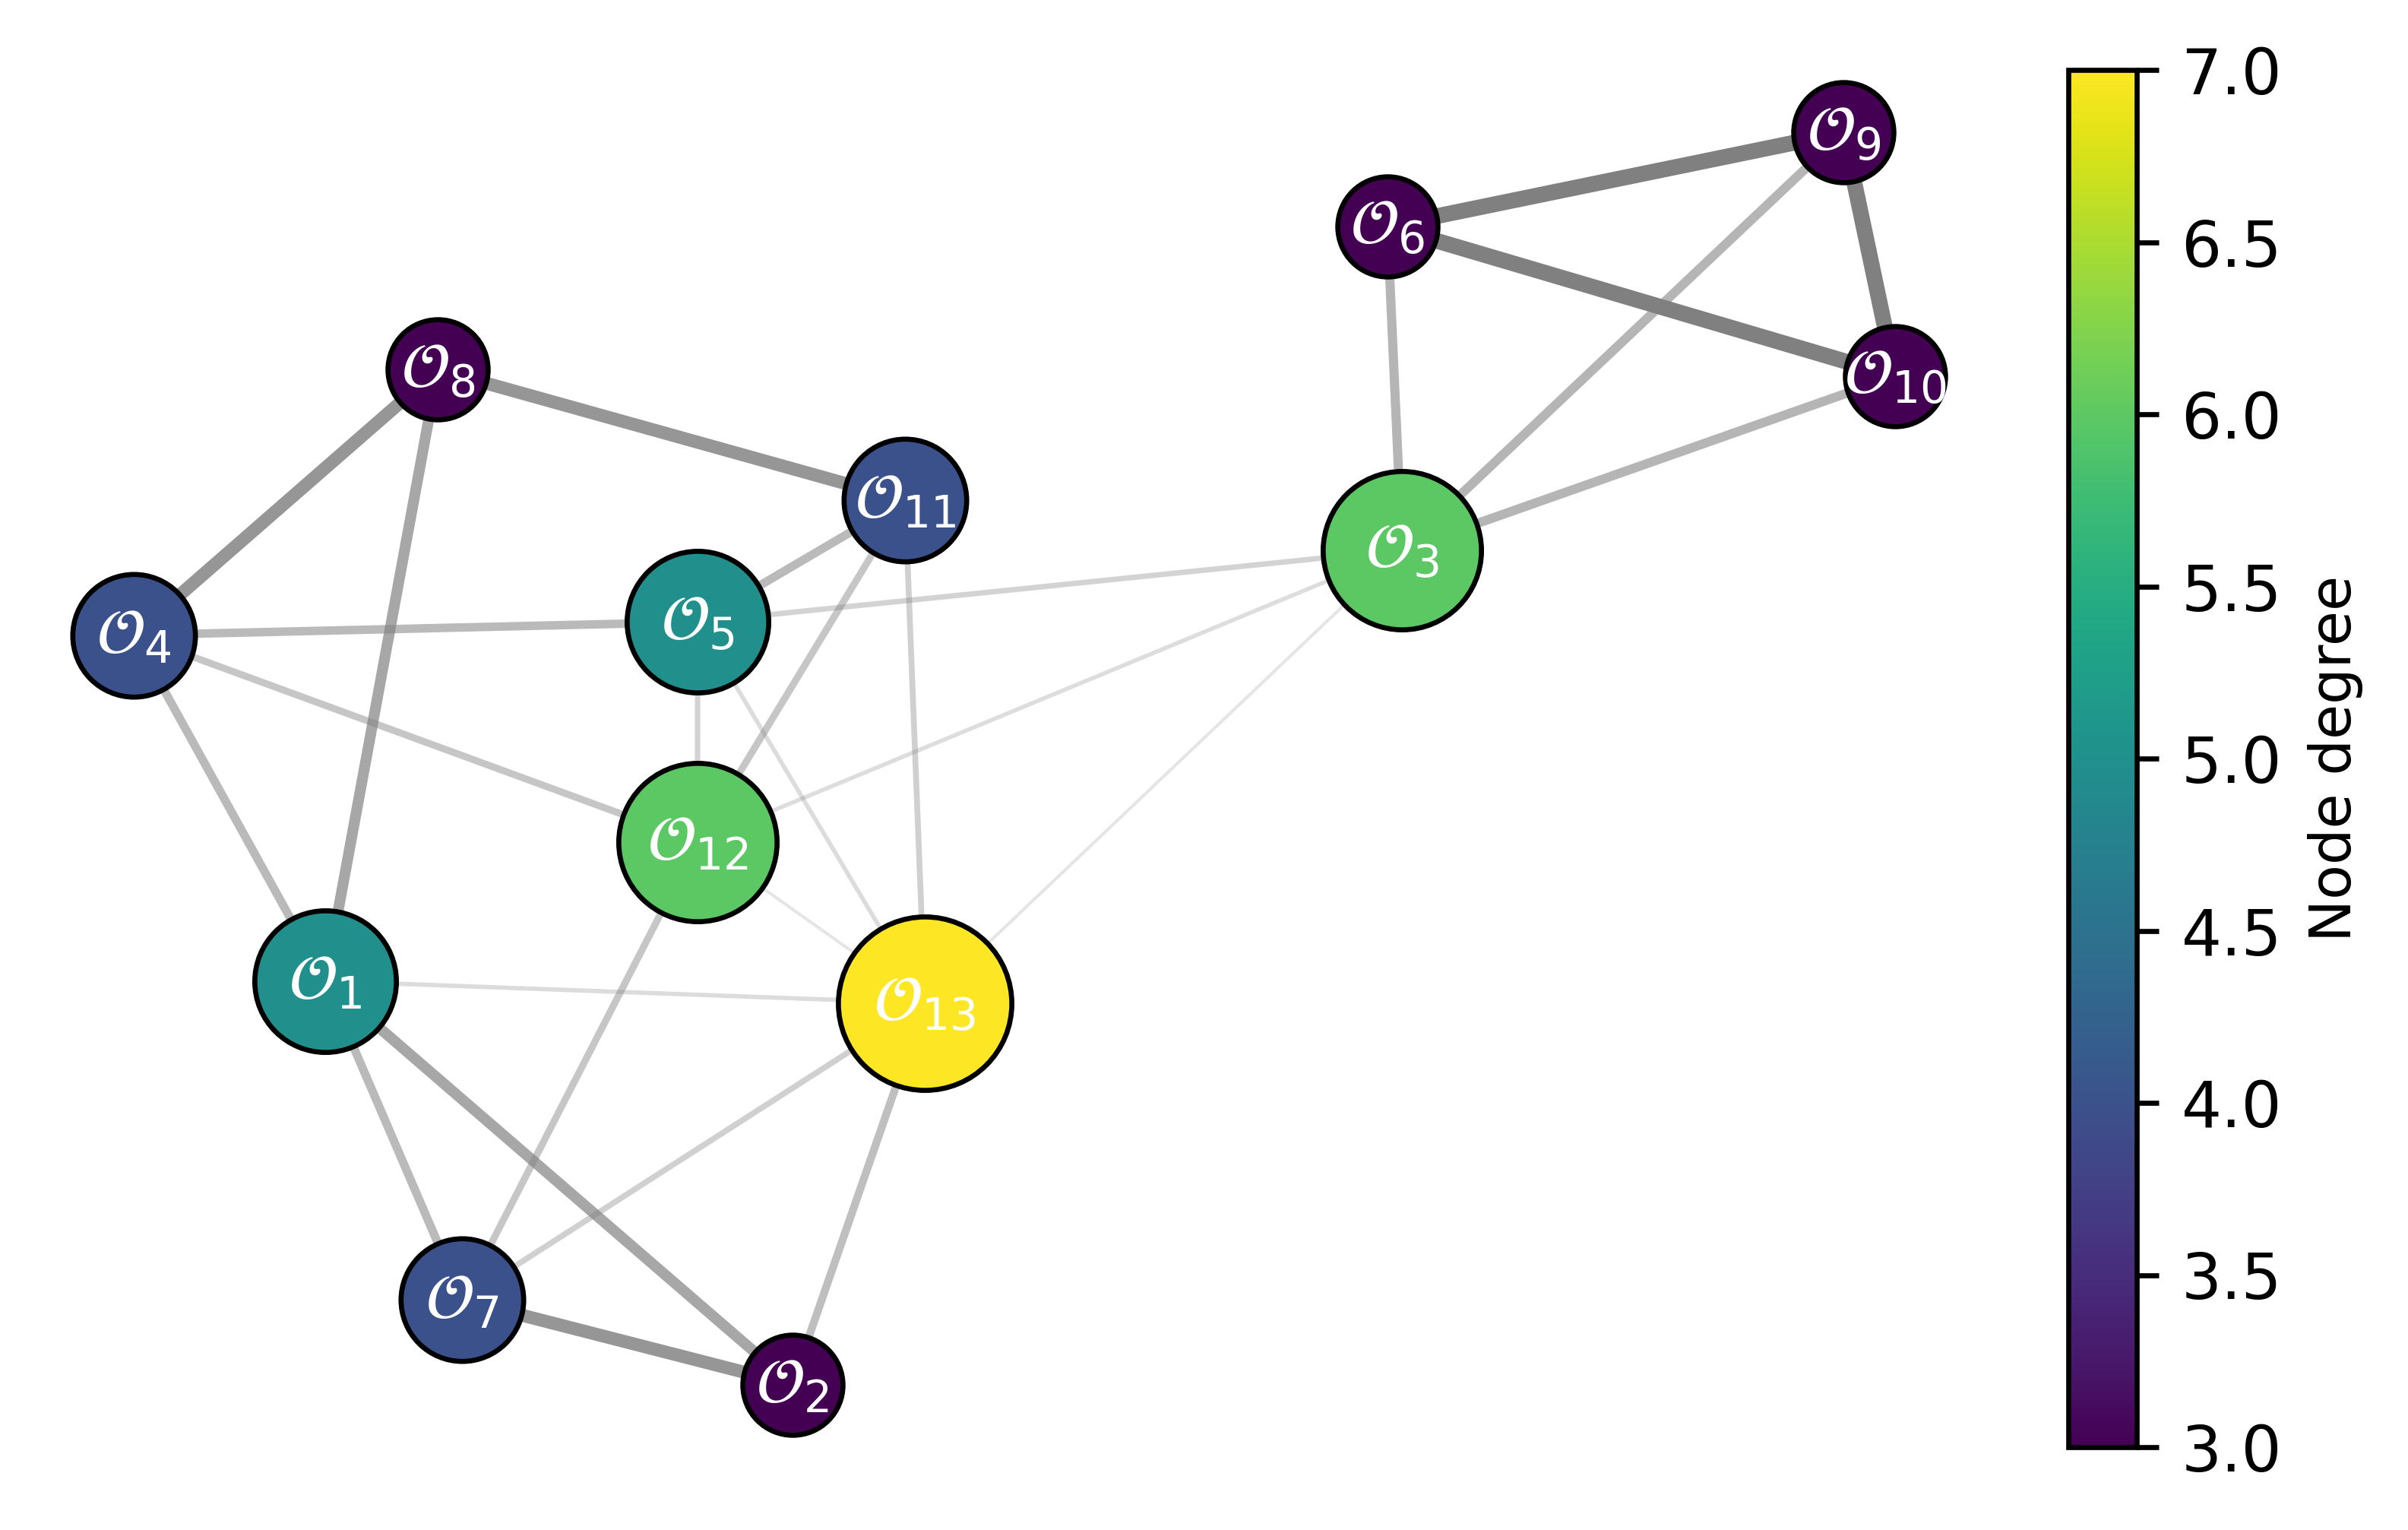

In [7]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import torch


w_e = torch.tensor([0.2506, 0.2519, 0.2607, 0.2368])
A_agg = torch.zeros_like(Ahat_list[0])
for k in range(num_graphs):
    A_agg += w_e[k] * Ahat_list[k]
# 转为cpu
A_vis = A_agg.detach().cpu().numpy()

# 图构建
G = nx.Graph()
num_nodes = A_vis.shape[0]

# 增加节点
for i in range(num_nodes):
    G.add_node(i)

# 加权边
threshold = 0.01
for i in range(num_nodes):
    for j in range(i + 1, num_nodes):
        if A_vis[i, j] > threshold:
            G.add_edge(i, j, weight=A_vis[i, j])

# 节点标签
labels = {i: rf'$\mathcal{{O}}_{{{i+1}}}$' for i in range(num_nodes)}

# Graph Layout
pos = nx.spring_layout(G, seed=21, k=0.6)

# Node Degree
degrees = dict(G.degree())
degree_values = np.array([degrees[i] for i in range(num_nodes)])

# Normalize Degree
degree_norm = (degree_values - degree_values.min()) / (degree_values.max() - degree_values.min() + 1e-8)

# 边权重
edge_weights = np.array([G[u][v]['weight'] for u, v in G.edges()])

edge_weights_norm = (edge_weights - edge_weights.min()) / (edge_weights.max() - edge_weights.min() + 1e-8)

# 可视化
fig = plt.figure(dpi=600)
ax1 = plt.subplot(1, 1, 1)

# 绘制边
for idx, (u, v) in enumerate(G.edges()):
    x1, y1 = pos[u]
    x2, y2 = pos[v]
    plt.plot([x1, x2],[y1, y2],color='gray',alpha=0.2 + 0.8 * edge_weights_norm[idx], linewidth=0.5 + 2.0 * edge_weights_norm[idx],zorder=1)

#  绘制节点
for node, (x, y) in pos.items():
    color = plt.cm.viridis(degree_norm[node])
    size = 250 + 500 * degree_norm[node]
    plt.scatter(
        x,
        y,
        s=size,
        color=color,
        edgecolors='black',
        linewidths=0.8,
        zorder=5
    )
    plt.text(
        x,
        y,
        labels[node],
        fontsize=10,
        ha='center',
        va='center',
        color='white',
        zorder=10
    )
plt.axis('off')

# 颜色棒
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis,norm=plt.Normalize(vmin=degree_values.min(),vmax=degree_values.max()))
sm.set_array([])
cbar = plt.colorbar(sm,ax=ax1,fraction=0.046,pad=0.04)
cbar.set_label('Node degree',fontsize=9)

plt.savefig("./GCN_Graph.jpg")
plt.show()

In [24]:
# ax2 = plt.figure(dpi = 600)
# im = plt.imshow(A_vis, cmap='viridis')

# plt.xticks(
#     ticks=np.arange(num_nodes),
#     labels=[rf'$\mathcal{{O}}_{{{i+1}}}$' for i in range(num_nodes)],
#     rotation=90,
#     fontsize=8
# )

# plt.yticks(
#     ticks=np.arange(num_nodes),
#     labels=[rf'$\mathcal{{O}}_{{{i+1}}}$' for i in range(num_nodes)],
#     fontsize=8
# )

# # Heatmap Colorbar
# cbar2 = plt.colorbar(im, fraction=0.046, pad=0.04)
# cbar2.set_label('Connectivity intensity',fontsize=9)

# plt.tight_layout()
# plt.savefig("./GCN_Graph_heatmap.jpg")
# plt.show()

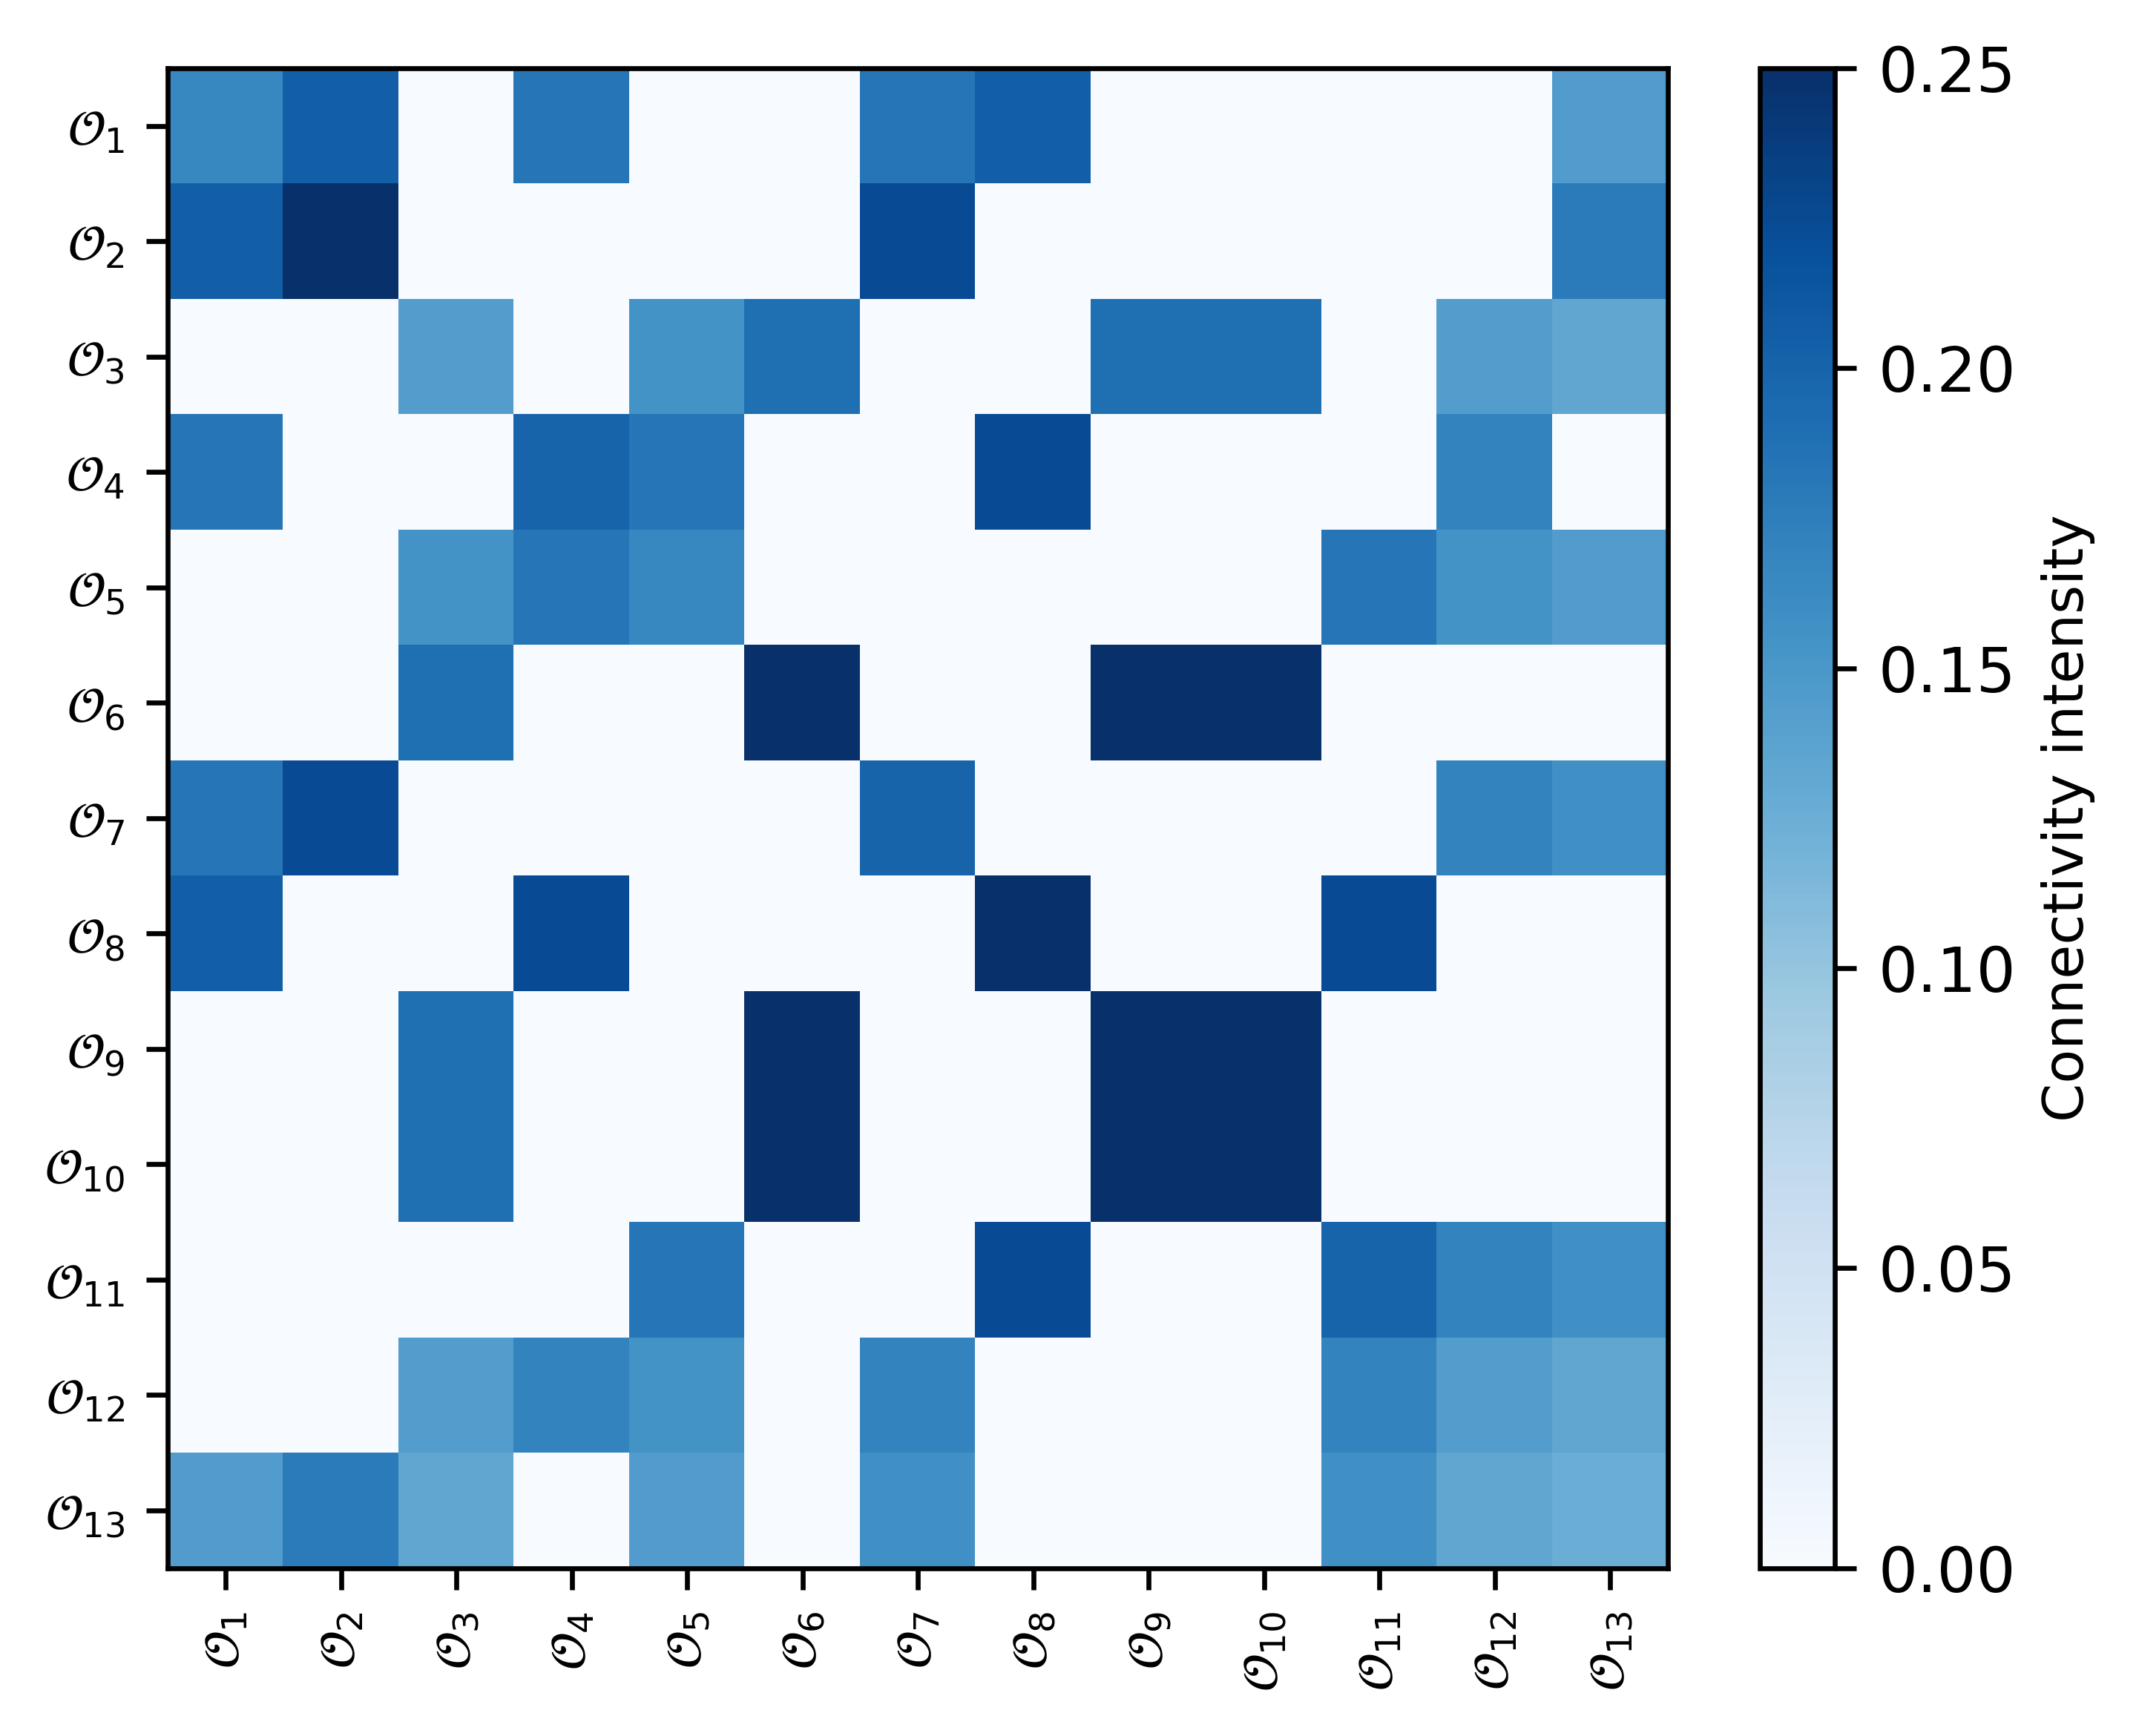

In [8]:
ax2 = plt.figure(dpi = 600)
im = plt.imshow(A_vis, cmap='Blues')

plt.xticks(
    ticks=np.arange(num_nodes),
    labels=[rf'$\mathcal{{O}}_{{{i+1}}}$' for i in range(num_nodes)],
    rotation=90,
    fontsize=8
)

plt.yticks(
    ticks=np.arange(num_nodes),
    labels=[rf'$\mathcal{{O}}_{{{i+1}}}$' for i in range(num_nodes)],
    fontsize=8
)

# Heatmap Colorbar
cbar2 = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar2.set_label('Connectivity intensity',fontsize=9)

plt.tight_layout()
plt.savefig("./GCN_Graph_heatmap.jpg")
plt.show()

# 模糊化+准则权重

In [5]:
from functools import reduce
import itertools
import numpy as np
import math
from sklearn import preprocessing
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation
from pyecharts import options as opts
from pyecharts.charts import Bar3D
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d import axes3d
from matplotlib.pyplot import MultipleLocator
from string import ascii_letters
import pandas as pd
import seaborn as sns
import palettable
from pylab import mpl

In [6]:
"""
GNN聚合后的原始数据
"""
X_GNN = [[1.2847, 0.0328, 0.9199, 0.5470, 0.9623, 1.0416],
        [1.4388, 0.2173, 0.9251, 0.3661, 0.7657, 1.0301],
        [0.5799, 0.4036, 0.5127, 0.3826, 0.3668, 0.6181],
        [0.6514, 0.0000, 0.6561, 0.5955, 0.7861, 0.7097],
        [1.0569, 0.2446, 1.1748, 0.8674, 0.9807, 1.2204],
        [0.3136, 0.3107, 0.2432, 0.2576, 0.2307, 0.3560],
        [1.4631, 0.2302, 1.0372, 0.4263, 0.8130, 1.0689],
        [0.1929, 0.1989, 0.1862, 0.1943, 0.1937, 0.1882],
        [0.3136, 0.3107, 0.2432, 0.2576, 0.2307, 0.3560],
        [0.3136, 0.3107, 0.2432, 0.2576, 0.2307, 0.3560],
        [0.3900, 0.2622, 0.5323, 0.5137, 0.4475, 0.6230],
        [1.2794, 0.2737, 1.2803, 0.8464, 1.0261, 1.3336],
        [1.5277, 0.3486, 1.2552, 0.6476, 0.9244, 1.3390]]
w_e = [0.2506, 0.2519, 0.2607, 0.2368]

# 成本准则索引
C_chengben = [5]
# q 值
q = 5
# 相对成本损失函数的参数（0~0.5）
theta = 0.1
# AA三角模的参数（≥1）
N_h = 2
# 算子系数参数
rho = 0.8
# 概率向量
PV = [1/6, 1/6, 1/6, 1/6, 1/6, 1/6]

In [7]:
"""
FuzzyNorm()：原始数据的模糊化和标准化，得到模糊矩阵U, V
"""
def FuzzyNorm(X, q, C_chengben, eps=0.05):
    if q < 1 or not 0 < eps < 1:
        raise ValueError("要求 q >= 1 且 0 < eps < 1")

    Min = []
    Max = []
    for i in range(len(X)):
        Min.append(min(X[i]))
        Max.append(max(X[i]))

    U = [[] for _ in range(len(X))]
    V = [[] for _ in range(len(X))]
    for i in range(len(X)):
        if Max[i] == Min[i]:
            raise ValueError(f"第 {i+1} 个方案的各属性取值相同，无法按原公式归一化")
        for j in range(len(X[0])):
            if j not in C_chengben:
                u = round((X[i][j] - Min[i]) / (Max[i] - Min[i]), 3)
                v = round((1 - u**q)**(1/q), 3)
            else:
                v = round((Max[i] - X[i][j]) / (Max[i] - Min[i]), 3)
                u = round((1 - v**q)**(1/q), 3)
            # Independent three-decimal rounding can cross the q-ROF boundary.
            # Keep the normalized component and lower only the derived one.
            if u**q + v**q > 1 + 1e-12:
                if j not in C_chengben:
                    v = int((max(0.0, 1-u**q)**(1/q))*1000 + 1e-12) / 1000
                else:
                    u = int((max(0.0, 1-v**q)**(1/q))*1000 + 1e-12) / 1000
            U[i].append(u)
            V[i].append(v)

    high = (1 - eps**q)**(1/q)
    if high >= 1.0:
        raise ValueError("当前 q 和 eps 使 high 在浮点精度下等于 1；请增大 eps")

    for i in range(len(U)):
        for j in range(len(U[0])):
            if U[i][j] == 0.0 and V[i][j] == 1.0:
                U[i][j] = eps
                V[i][j] = high
            elif U[i][j] == 1.0 and V[i][j] == 0.0:
                U[i][j] = high
                V[i][j] = eps

    return U, V


In [8]:
"""
Cal_w_c()：基于熵值和准则去除效果计算准则矩阵w_c
"""
def Cal_w_c(U, V, q):
    # 储存犹豫度矩阵 m*n
    r_youyu = [[] for i in range(len(U))] 
    for i in range(len(U)):
        for j in range(len(U[0])):
            guocheng  = max(0, (1 - U[i][j]**q - V[i][j]** q))
            r_youyu[i].append(guocheng**(1/q))
    # 储存熵矩阵 m*n
    E_shang = [[] for i in range(len(U))]
    for i in range(len(U)):
        for j in range(len(U[0])):
            E_shang[i].append(round((U[i][j]**q * V[i][j]**q + r_youyu[i][j]**q) / ((1/4) * (U[i][j]**q + V[i][j]**q)**2 + r_youyu[i][j]**q),3))
#     print(E_shang)
#     print('------------------------------')
    # 储存准则去除前的性能矩阵 1*m
    list_one = [1 for i in range(len(U))]
    list_E = np.mean(E_shang, axis=1).tolist()
    Perf = [round(a - b, 3) for a, b in zip(list_one, list_E)]
    # 储存准则去除后的性能矩阵 n*m
    Perf_out = []
    for k in range(len(U[0])):
        E_shang_out = [[] for i in range(len(U))]
        for i in range(len(U)):
            for j in range(len(U[0])):
                if j == k:
                    E_shang_out[i].append(0)
                else:
                    E_shang_out[i].append(E_shang[i][j])
        list_one = [1 for i in range(len(U))]
        list_E_out = np.mean(E_shang_out, axis=1).tolist()
        Perf_out.append([round(a - b, 3) for a, b in zip(list_one, list_E_out)])
#     print(Perf_out)
#     print('------------------------------')
    # 储存准则去除前后的差值 n*m
    sum_Perf = []
    for k in range(len(U[0])):
        sum_Perf.append(round(np.sum([abs(a - b) for a, b in zip(Perf_out[k], Perf)]), 3))
#     print(sum_Perf)
#     print('------------------------------')
    # 储存准则权重
    w_c = []
    for i in range(len(sum_Perf)):
        w_c.append(round(sum_Perf[i] / sum(sum_Perf), 3))
    return Perf, w_c

In [9]:
"""
部分q阶模糊数运算法则
"""
def q_diancheng(k, m, n, q):
    u = (1 - np.exp(-((k * (-np.log(1 - m ** q)) ** N_h) ** (1/N_h)))) ** (1/q)
    v = (np.exp(-((k * (-np.log(n ** q)) ** N_h) ** (1/N_h)))) ** (1/q)
    return u, v

def q_cheng(m1, n1, m2, n2, q):
    u = (np.exp(-(((-np.log(m1 ** q)) ** N_h + (-np.log(m2 ** q)) ** N_h) ** (1/N_h)))) ** (1/q)
    v = (1 - np.exp(-(((-np.log(1 - n1 ** q)) ** N_h + (-np.log(1 - n2 ** q)) ** N_h) ** (1/N_h)))) ** (1/q)
    return u, v

def q_jia(m1, n1, m2, n2, q):
    u = (1 - np.exp(-(((-np.log(1 - m1 ** q)) ** N_h + (-np.log(1 - m2 ** q)) ** N_h) ** (1/N_h)))) ** (1/q)
    v = (np.exp(-(((-np.log(n1 ** q)) ** N_h + (-np.log(n2 ** q)) ** N_h) ** (1/N_h)))) ** (1/q)
    return u, v


# 非AA
# def q_diancheng(k, m, n, q):
#     u = (1 - (1 - m ** q) ** k) ** (1/q)
#     v = n ** k
#     return u, v
# def q_cheng(m1, n1, m2, n2, q):
#     u = m1 * m2
#     v = (n1 ** q + n2 ** q - (n1 * n2) ** q) ** (1/q)
#     return u, v
# def q_jia(m1, n1, m2, n2, q):
#     u = (m1 ** q + m2 ** q - (m1 * m2) ** q) ** (1/q)
#     v = n1 * n2
#     return u, v

def q_chu(m1, n1, m2, n2, q):
    if m2 != 0:
        u = min(1, m1/m2)
    else:
        u = 1
        
    if 1 - n2 ** q != 0:
        v = max(0, (((n1 ** q - n2 ** q) * 10000) / ((1 - n2 ** q) * 10000)) ** (1/q))
    else:
        v = 0
    return u, v

"""
scalar_value():计算标量值函数
输出：
cal_sv：标量值函数
"""
def scalar_value(m, n, q):
    cal_sv = 1/2 + ((m ** q + n ** q) ** (1/q)) * (1/2 - (2 * np.arccos(m / ((m ** q + n ** q) ** (1/q))) / np.pi))
    return cal_sv

In [10]:
"""
Cal_rank()：计算用于排序的模糊数 U_rank, V_rank
"""
def Cal_rank(U, V, q, w_c, rho, PV, N_h):
    U_rank = []
    V_rank = []
    for i in range(len(U)): # 技术
        a_u = 0
        b_u = 0
        a_v = 0
        b_v = 0
        for j in range(len(U[0])): # 准则
            a_u += w_c[j] * (-np.log(1 - U[i][j] ** q)) ** N_h
            b_u += PV[j] * (-np.log(1 - U[i][j] ** q)) ** N_h
            a_v += w_c[j] * (-np.log(V[i][j] ** q)) ** N_h
            b_v += PV[j] * (-np.log(V[i][j] ** q)) ** N_h
        U_rank.append(round(1 - (np.exp(-(rho * a_u + (1 - rho) * b_u) ** (1/N_h))) ** (1/q), 3))
        V_rank.append(round((np.exp(-(rho * a_v + (1 - rho) * b_v) ** (1/N_h))) ** (1/q), 3))
    return U_rank, V_rank

In [11]:
"""
SCORE()：得分与排名
"""
def SCORE(U_rank, V_rank, q, Perf):
    Score = []
    Score_original = 0
    for i in range(len(U_rank)):
        Youyu_cifang = 1 - U_rank[i] ** q - V_rank[i] ** q
        Score_original = U_rank[i] ** q - V_rank[i] ** q - Youyu_cifang * np.log2(1+Youyu_cifang) / 100
        Score.append(round((Score_original + 1) / 2, 3))
    Final_Score = []
    for i in range(len(Score)):
        Final_Score.append(round((Score[i] + Perf[i]) - Score[i] * Perf[i], 3))
    
        
    # 各技术的排名（Score从大到小排序）
    Score_paixu_id = sorted(range(len(Final_Score)), key = lambda k: Final_Score[k], reverse = True)
    for i in range(len(Score)):
        Score_paixu_id[i] += 1
    return Final_Score, Score_paixu_id

In [12]:
"""
cal_cucao()：计算各技术的粗糙近似阈值
隐含：
a_PP_U ,a_PP_V,a_BP_U,a_BP_V,a_NP_U,a_NP_V,a_PN_U,a_PN_V,a_BN_U,a_BN_V,a_NN_U ,a_NN_V：各技术的相对成本损失函数值
输出：
P_U,P_V：标准评估集
w：聚合后的各技术权重  
fai_P_U,fai_P_V：各技术的单个隶属度
c_cucao：各技术的粗糙近似阈值
"""
def cal_cucao(U_juhe, V_juhe, U_rank, V_rank, q, w_c, theta, Perf, N_h):
    w = w_c

    # 计算各对象的相对成本损失函数值
    a_PP_U = []
    a_PP_V = []
    a_BP_U = []
    a_BP_V = []
    a_NP_U = []
    a_NP_V = []
    a_PN_U = []
    a_PN_V = []
    a_BN_U = []
    a_BN_V = []
    a_NN_U = []
    a_NN_V = []
    for i in range(len(U_juhe)):
        values = SCORE(U_juhe[i], V_juhe[i], q, Perf)[0]
        max_index = values.index(max(values))
        min_index = values.index(min(values))
        MAX_U = U_juhe[i][max_index]
        MAX_V = V_juhe[i][max_index]
        MIN_U = U_juhe[i][min_index]
        MIN_V = V_juhe[i][min_index]
        Min_rho_U = q_jia(U_rank[i], V_rank[i], q_diancheng(1, MIN_U, MIN_V, q)[0], q_diancheng(1, MIN_U, MIN_V, q)[1], q)[0]
        Min_rho_V = q_jia(U_rank[i], V_rank[i], q_diancheng(1, MIN_U, MIN_V, q)[0], q_diancheng(1, MIN_U, MIN_V, q)[1], q)[1]
        Max_rho_U = q_jia(MAX_U, MAX_V, q_diancheng(1, U_rank[i], V_rank[i], q)[0], q_diancheng(1, U_rank[i], V_rank[i], q)[1], q)[0]
        Max_rho_V = q_jia(MAX_U, MAX_V, q_diancheng(1, U_rank[i], V_rank[i], q)[0], q_diancheng(1, U_rank[i], V_rank[i], q)[1], q)[1]
        
        
        a_PP_U.append(0)
        a_PP_V.append(1)
        a_BP_U.append(round(q_diancheng(theta, Min_rho_U, Min_rho_V, q)[0], 3))
        a_BP_V.append(round(q_diancheng(theta, Min_rho_U, Min_rho_V, q)[1], 3))
        a_NP_U.append(round(Min_rho_U, 3))
        a_NP_V.append(round(Min_rho_V, 3))
        a_PN_U.append(round(Max_rho_U, 3))
        a_PN_V.append(round(Max_rho_V, 3))
        a_BN_U.append(round(q_diancheng(theta, Max_rho_U, Max_rho_V, q)[0], 3))
        a_BN_V.append(round(q_diancheng(theta, Max_rho_U, Max_rho_V, q)[1], 3))
        a_NN_U.append(0)
        a_NN_V.append(1)   
#     print('a_PP_U:\n', a_PP_U)
#     print('a_PP_V:\n', a_PP_V)   
#     print('a_BP_U:\n', a_BP_U)
#     print('a_BP_V:\n', a_BP_V)
#     print('a_NP_U:\n', a_NP_U)
#     print('a_NP_V:\n', a_NP_V)  
#     print('a_PN_U:\n', a_PN_U)
#     print('a_PN_V:\n', a_PN_V)  
#     print('a_BN_U:\n', a_BN_U)
#     print('a_BN_V:\n', a_BN_V)
#     print('a_NN_U:\n', a_NN_U)
#     print('a_NN_V:\n', a_NN_V)  
      
    # 计算各对象的粗糙近似阈值
    c_cucao = [[] for i in range(2)]
    fai_PP = []
    fai_BP = []
    fai_NP = []
    fai_PN = []
    fai_BN = []
    fai_NN = []
    for i in range(len(U_juhe)):
        fai_PP.append(round(scalar_value(a_PP_U[i], a_PP_V[i], q), 4))
        fai_BP.append(round(scalar_value(a_BP_U[i], a_BP_V[i], q), 4))
        fai_NP.append(round(scalar_value(a_NP_U[i], a_NP_V[i], q), 4))
        fai_PN.append(round(scalar_value(a_PN_U[i], a_PN_V[i], q), 4))
        fai_BN.append(round(scalar_value(a_BN_U[i], a_BN_V[i], q), 4))
        fai_NN.append(round(scalar_value(a_NN_U[i], a_NN_V[i], q), 4))
    for i in range(len(U_juhe)):
        c_cucao[0].append(round((fai_PN[i] - fai_BN[i])/(fai_PN[i] - fai_BN[i] + fai_BP[i] - fai_PP[i]), 4)) # α
        c_cucao[1].append(round((fai_BN[i] - fai_NN[i])/(fai_BN[i] - fai_NN[i] + fai_NP[i] - fai_BP[i]), 4)) # β
#     print(c_cucao[0])
#     print(c_cucao[1])
    
    return c_cucao

In [13]:
def TWDsRegions(Perf, Score):
    POS = []
    BND = []
    NEG = []
    for i in range(len(Score)):
        if Score[i] >=c_cucao[1][i]:
            POS.append('O'+ str(i+1))
        elif c_cucao[0][i] < Score[i] <c_cucao[1][i]:
            BND.append('O'+ str(i+1))
        else:
            NEG.append('O'+ str(i+1))
    return POS, BND, NEG

# 模型运行

In [14]:
U, V = FuzzyNorm(X_GNN , q, C_chengben)
# U = [[0.964, 0.011, 0.709, 0.411, 0.742, 0.957],
#  [0.957, 0.018, 0.579, 0.122, 0.449, 0.999],
#  [0.848, 0.146, 0.581, 0.063, 0.026, 0.975],
#  [0.829, 0.007, 0.835, 0.758, 0.97, 0.966],
#  [0.832, 0.003, 0.953, 0.638, 0.754, 0.955],
#  [0.662, 0.638, 0.1, 0.215, 0.014, 0.99],
#  [0.98, 0.048, 0.655, 0.159, 0.473, 0.999],
#  [0.528, 0.956, 0.045, 0.638, 0.591, 0.895],
#  [0.662, 0.638, 0.1, 0.215, 0.023, 0.98],
#  [0.662, 0.638, 0.1, 0.215, 0.043, 0.977],
#  [0.354, 0.004, 0.749, 0.697, 0.514, 0.987],
#  [0.949, 0.009, 0.95, 0.54, 0.71, 0.963],
#  [0.972, 0.03, 0.769, 0.254, 0.488, 0.999]]
# V = [[0.005, 0.976, 0.961, 0.998, 0.95, 0.002],
#  [0.031, 0.966, 0.987, 0.999, 0.996, 0.335],
#  [0.891, 0.999, 0.986, 0.999, 0.957, 0.015],
#  [0.905, 0.968, 0.901, 0.944, 0.021, 0.001],
#  [0.903, 0.999, 0.735, 0.978, 0.946, 0.02],
#  [0.973, 0.978, 0.999, 0.999, 0.997, 0.042],
#  [0.018, 0.953, 0.975, 0.999, 0.995, 0.32],
#  [0.992, 0.004, 0.957, 0.978, 0.985, 0.843],
#  [0.973, 0.978, 0.999, 0.999, 0.987, 0.047],
#  [0.973, 0.978, 0.999, 0.999, 0.974, 0.004],
#  [0.999, 0.978, 0.948, 0.965, 0.993, 0.018],
#  [0.746, 0.981, 0.743, 0.991, 0.961, 0.03],
#  [0.016, 0.979, 0.939, 0.999, 0.994, 0.035]]

# U = [[0.983, 0.035, 0.709, 0.411, 0.742, 0.997],
#   [0.977, 0.036, 0.579, 0.122, 0.449, 0.987],
#   [0.848, 0.146, 0.581, 0.063, 0.009, 0.954],
#   [0.828, 0.037, 0.835, 0.758, 0.986, 0.950],
#   [0.832, 0.031, 0.953, 0.638, 0.754, 0.987],
#   [0.662, 0.638, 0.100, 0.215, 0.030, 0.991], # 6
#   [0.963, 0.007, 0.655, 0.159, 0.473, 0.988],
#   [0.528, 0.991, 0.019, 0.638, 0.591, 0.737],
#   [0.662, 0.638, 0.100, 0.215, 0.041, 0.996], # 9
#   [0.662, 0.638, 0.100, 0.215, 0.012, 0.958], # 10
#   [0.354, 0.008, 0.749, 0.697, 0.514, 0.967],
#   [0.949, 0.014, 0.950, 0.540, 0.710, 0.955],
#   [0.985, 0.023, 0.769, 0.254, 0.488, 0.998]]
# V = [[0.005, 0.959, 0.863, 0.976, 0.839, 0.194],
#   [0.032, 0.992, 0.930, 0.999, 0.968, 0.335],
#   [0.730, 0.998, 0.929, 0.999, 0.985, 0.028],
#   [0.755, 0.960, 0.747, 0.826, 0.041, 0.018],
#   [0.751, 0.974, 0.512, 0.904, 0.829, 0.029],
#   [0.892, 0.904, 0.999, 0.996, 0.954, 0.008], # 6
#   [0.032, 0.961, 0.895, 0.998, 0.963, 0.320],
#   [0.948, 0.017, 0.982, 0.904, 0.925, 0.843],
#   [0.892, 0.904, 0.999, 0.996, 0.988, 0.028], # 9
#   [0.892, 0.904, 0.999, 0.996, 0.997, 0.031], # 10
#   [0.984, 0.980, 0.833, 0.871, 0.952, 0.039],
#   [0.525, 0.960, 0.522, 0.944, 0.862, 0.039],
#   [0.001, 0.999, 0.816, 0.994, 0.959, 0.160]]
Perf, w_c = Cal_w_c(U, V, q)
U_rank, V_rank = Cal_rank(U, V, q, w_c, rho, PV, N_h)
Score, Score_paixu_id = SCORE(U_rank, V_rank, q, Perf)
c_cucao = cal_cucao(U, V, U_rank, V_rank, q, w_c, theta, Perf, N_h)
POS, BND, NEG = TWDsRegions(Perf, Score)


# [13, 1, 2, 4, 7, 9, 5, 8, 12, 6, 11, 3, 10]
# O13 > O1 > ... > O3 > O10

In [15]:
print(w_c)

[0.285, 0.066, 0.301, 0.137, 0.152, 0.06]


In [16]:
print(U_rank)
print(V_rank)
print(Score)
print(Score_paixu_id)
print(c_cucao[0])
print(c_cucao[1])
print(POS, BND, NEG)

[0.79, 0.79, 0.575, 0.705, 0.582, 0.575, 0.79, 0.585, 0.575, 0.575, 0.575, 0.586, 0.79]
[0.202, 0.21, 0.425, 0.258, 0.418, 0.425, 0.209, 0.415, 0.425, 0.425, 0.425, 0.414, 0.198]
[0.92, 0.978, 0.898, 0.813, 0.781, 0.93, 0.967, 0.857, 0.93, 0.93, 0.882, 0.826, 0.945]
[2, 7, 13, 6, 9, 10, 1, 3, 11, 8, 12, 4, 5]
[0.0413, 0.0421, 0.0748, 0.047, 0.0673, 0.0748, 0.0419, 0.0695, 0.0748, 0.0748, 0.0734, 0.0708, 0.0409]
[0.805, 0.8032, 0.7834, 0.792, 0.779, 0.7834, 0.8031, 0.7801, 0.7834, 0.7834, 0.7824, 0.7804, 0.8061]
['O1', 'O2', 'O3', 'O4', 'O5', 'O6', 'O7', 'O8', 'O9', 'O10', 'O11', 'O12', 'O13'] [] []


# 参考方案+正确率比较

In [144]:
from itertools import permutations
from collections import defaultdict
import numpy as np
from itertools import combinations

def compute_winner_matrix(rankings, elements):
    """计算胜者矩阵，统计每对元素在所有排序中谁更靠前"""
    n = len(elements)
    element_index = {elem: i for i, elem in enumerate(elements)}
    M = np.zeros((n, n))  # M[i][j] 代表元素 i 在方法中比 j 靠前的次数
    
    for ranking in rankings:
        for i in range(n):
            for j in range(i+1, n):
                if ranking.index(elements[i]) < ranking.index(elements[j]):
                    M[i][j] += 1
                else:
                    M[j][i] += 1
    return M

def kemeny_young_heuristic(rankings):
    """基于胜者矩阵的 Kemeny-Young 启发式方法"""
    elements = list(rankings[0])  # 获取所有元素
    M = compute_winner_matrix(rankings, elements)
    
    # 计算每个元素的胜出分数（获胜次数 - 失败次数）
    scores = np.sum(M > M.T, axis=1)  # 统计每个元素比其他元素更强的次数
    
    # 根据胜出分数排序，得出近似的 Kemeny-Young 排序
    sorted_elements = [x for _, x in sorted(zip(scores, elements), reverse=True)]
    
    return sorted_elements

# 创建映射，给每个元素赋一个排名
def create_rank_map(sort_list):
    return {item: i for i, item in enumerate(sort_list)}

# 计算排序中的相对顺序对
def count_correct_pairs(method_sort, reference_rank_map):
    correct_pairs = 0
    total_pairs = 0
    # 生成所有可能的元素对
    for (item1, item2) in combinations(method_sort, 2):
        total_pairs += 1
        # 获取两个元素在参考排序中的排名
        rank1 = reference_rank_map[item1]
        rank2 = reference_rank_map[item2]
        # 如果两个元素的相对顺序在排序方法和参考排序中一致，则认为是正确的对
        if (rank1 < rank2 and method_sort.index(item1) < method_sort.index(item2)) or \
           (rank1 > rank2 and method_sort.index(item1) > method_sort.index(item2)):
            correct_pairs += 1
    return correct_pairs, total_pairs

# 排序方案，用于后续计算正确排序方案
def Scheme(Score_paixu_id):
    Scheme = []
    for i in range(len(Score_paixu_id)):
        Scheme.append('O' + str(Score_paixu_id[i]))
    return Scheme 

# 敏感分析1略；2

In [114]:
"""
GNNTWDMAGDM()：文章函数
"""
def GNNTWDMAGDM(U, V, q, N_h, rho, PV, theta):
    Perf, w_c = Cal_w_c(U, V, q)
    U_rank, V_rank = Cal_rank(U, V, q, w_c, rho, PV, N_h)
    Score, Score_paixu_id = SCORE(U_rank, V_rank, q, Perf)
    c_cucao = cal_cucao(U, V, U_rank, V_rank, q, w_c, theta, Perf, N_h)
    POS, BND, NEG = TWDsRegions(Perf, Score)
    SchemeSen = Scheme(Score_paixu_id)
    return Perf, w_c, U_rank, V_rank, Score, Score_paixu_id, c_cucao, POS, BND, NEG, SchemeSen

In [121]:
# 算子幂参:123456
if __name__ == "__main__":
    Perf, w_c, U_rank, V_rank, Score, Score_paixu_id, c_cucao, POS, BND, NEG, SchemeSen = GNNTWDMAGDM(U, V,
        5, # q 值
        6, # 算子幂参数，也是AA三角模的参数（≥1）
        0.8, # 算子系数参数
        [1/6, 1/6, 1/6, 1/6, 1/6, 1/6], # 算子概率向量
        0.1) # 相对成本损失函数的参数（0~0.5）
    
    print('技术排名：\n', Score_paixu_id)
    print('排名方案：\n', SchemeSen)
    print('分类结果：\n', POS, BND, NEG)

技术排名：
 [13, 2, 9, 10, 6, 3, 7, 1, 11, 8, 12, 5, 4]
排名方案：
 ['O13', 'O2', 'O9', 'O10', 'O6', 'O3', 'O7', 'O1', 'O11', 'O8', 'O12', 'O5', 'O4']
分类结果：
 ['O2'] ['O1', 'O3', 'O4', 'O5', 'O6', 'O7', 'O8', 'O9', 'O10', 'O11', 'O12', 'O13'] []


In [122]:

# 测试数据：三种排序方法
methods = [['O13', 'O2', 'O9', 'O10', 'O6', 'O7', 'O3', 'O1', 'O8', 'O11', 'O12', 'O5', 'O4'], # 1
           ['O2', 'O13', 'O9', 'O10', 'O6', 'O3', 'O7', 'O1', 'O11', 'O8', 'O12', 'O5', 'O4'],# 2
           ['O2', 'O13', 'O9', 'O10', 'O6', 'O3', 'O7', 'O1', 'O11', 'O8', 'O12', 'O5', 'O4'],# 3
           ['O2', 'O13', 'O9', 'O10', 'O6', 'O3', 'O7', 'O1', 'O11', 'O8', 'O12', 'O5', 'O4'],# 4
           ['O13', 'O2', 'O9', 'O10', 'O6', 'O3', 'O7', 'O1', 'O11', 'O8', 'O12', 'O5', 'O4'],# 5
           ['O13', 'O2', 'O9', 'O10', 'O6', 'O3', 'O7', 'O1', 'O11', 'O8', 'O12', 'O5', 'O4']] # 6

kemeny_young_sort = kemeny_young_heuristic(methods)
print("Kemeny-Young 近似排序:", kemeny_young_sort)
# 创建参考排序的排名映射
reference_rank_map = create_rank_map(kemeny_young_sort)

# 计算每个方法的正确率
accuracies = []
for method_sort in methods:
    correct_pairs, total_pairs = count_correct_pairs(method_sort, reference_rank_map)
    accuracy = correct_pairs / total_pairs if total_pairs > 0 else 0
    accuracies.append(accuracy)

# 输出结果
print(accuracies)

Kemeny-Young 近似排序: ['O2', 'O13', 'O9', 'O10', 'O6', 'O3', 'O7', 'O1', 'O11', 'O8', 'O12', 'O5', 'O4']
[0.9615384615384616, 1.0, 1.0, 1.0, 0.9871794871794872, 0.9871794871794872]


<ipython-input-2-f8f38706e23f>:24: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  fig.tight_layout()
<ipython-input-2-f8f38706e23f>:96: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  fig.tight_layout()


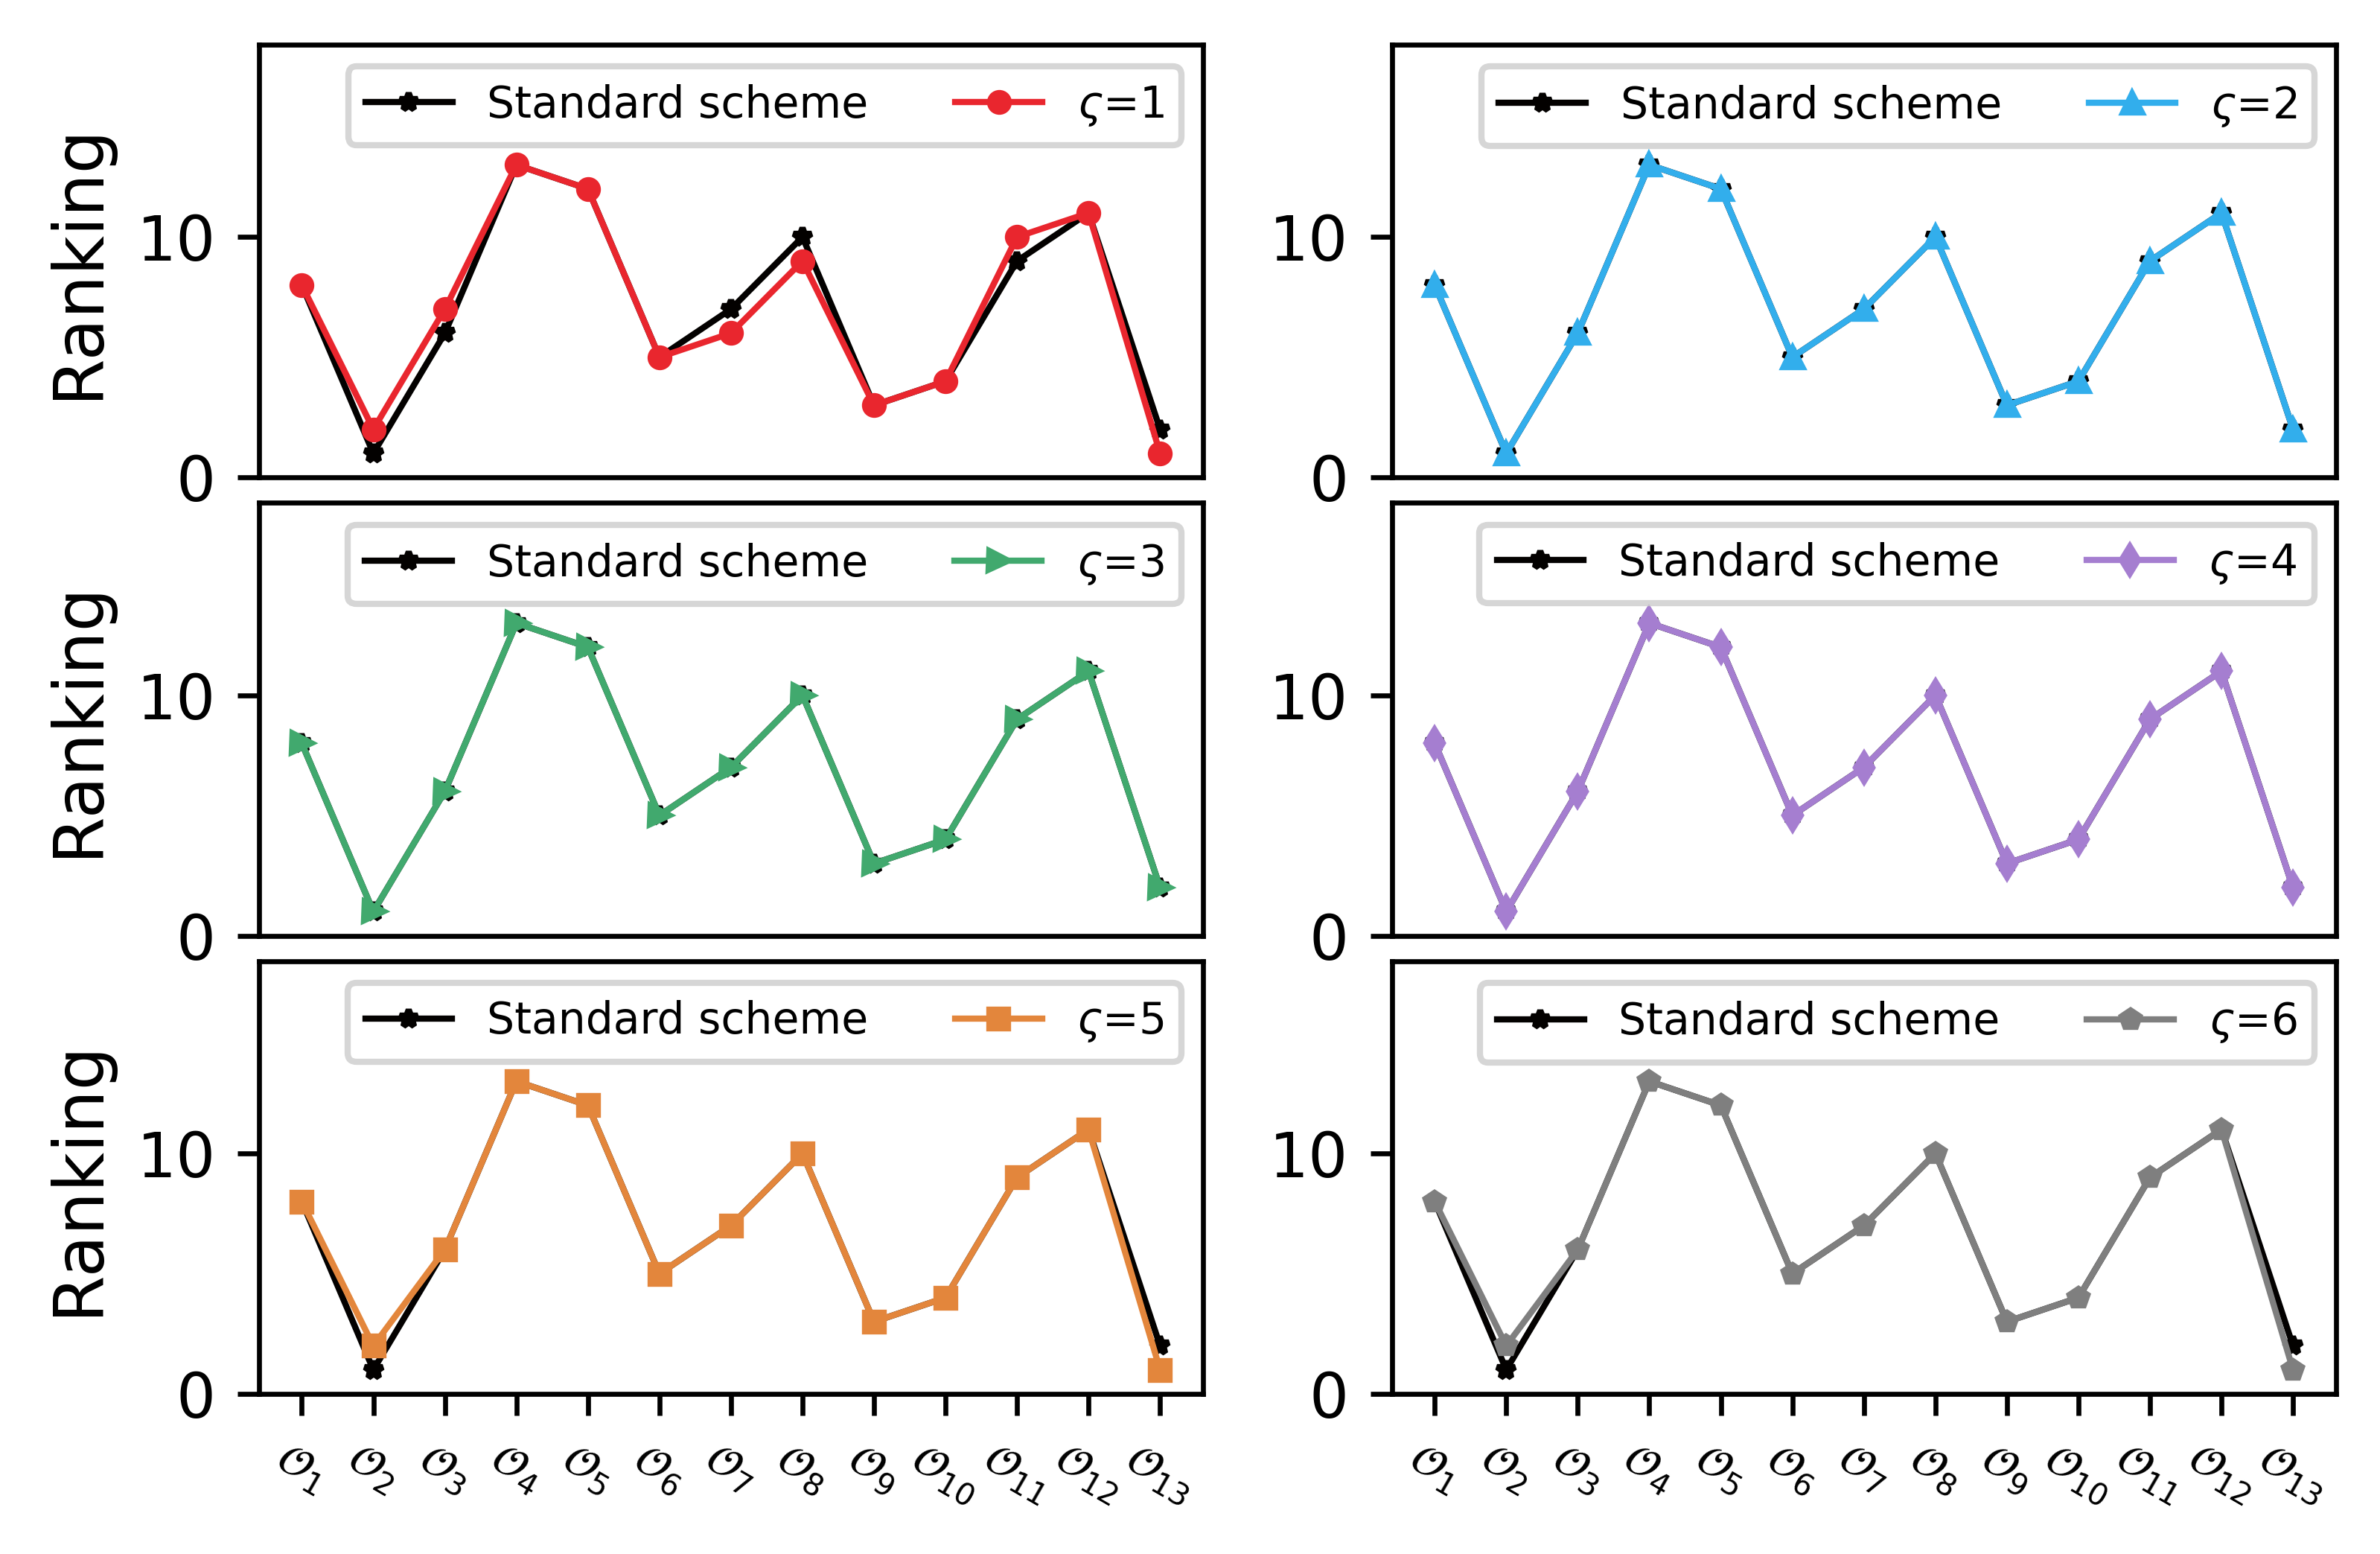

In [2]:
from matplotlib.gridspec import GridSpec
x = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2]
Name = [r'$\mathcal{O}_{1}$', r'$\mathcal{O}_{2}$', r'$\mathcal{O}_{3}$', r'$\mathcal{O}_{4}$', r'$\mathcal{O}_{5}$', r'$\mathcal{O}_{6}$', r'$\mathcal{O}_{7}$', r'$\mathcal{O}_{8}$', r'$\mathcal{O}_{9}$', r'$\mathcal{O}_{10}$', r'$\mathcal{O}_{11}$', r'$\mathcal{O}_{12}$', r'$\mathcal{O}_{13}$']
Name_none = ['','','','','','','','','','','','','']
# 注意更换排名与技术序号的信息
#     1  2  3   4   5  6  7  8   9  10 11  12  13 
A0 = [8, 1, 6, 13, 12, 5, 7, 10, 3, 4, 9, 11, 2] # 参考方案
A1 = [8, 2, 7, 13, 12, 5, 6, 9, 3, 4, 10, 11, 1] # 1
A2 = [8, 1, 6, 13, 12, 5, 7, 10, 3, 4, 9, 11, 2] # 2
A3 = [8, 1, 6, 13, 12, 5, 7, 10, 3, 4, 9, 11, 2] # 3
A4 = [8, 1, 6, 13, 12, 5, 7, 10, 3, 4, 9, 11, 2] # 4
A5 = [8, 2, 6, 13, 12, 5, 7, 10, 3, 4, 9, 11, 1] # 5
A6 = [8, 2, 6, 13, 12, 5, 7, 10, 3, 4, 9, 11, 1] # 6

fig = plt.figure(dpi = 600)
# method1：GridSpec(nrow,ncol)函数：把子图网格化
gs = GridSpec(9, 2) # 生成一个9行3列的子图网格，传出的数据是数组
sub1 = fig.add_subplot(gs[0:3, 0]) # 一个subplot可以占用多个GridSpace网格。其中0:3取得的数组下标为0、1、2，分别代表第1、2、3行。
sub2 = fig.add_subplot(gs[0:3, 1])
sub3 = fig.add_subplot(gs[3:6, 0])
sub4 = fig.add_subplot(gs[3:6, 1])
sub5 = fig.add_subplot(gs[6:9, 0])
sub6 = fig.add_subplot(gs[6:9, 1])
fig.tight_layout()


line1 = sub1.plot(x, A0, color = '#030100', label = 'Standard scheme', 
                 marker = '*', markersize = 3, linewidth = 1)
line2 = sub1.plot(x, A1, color = '#E9262E', label = r'$\varsigma$=1', 
                 marker = 'o', markersize = 3, linewidth = 1)
# sub1.set_xlabel('Jurisdiction', fontsize = 11)
sub1.set_ylabel('Ranking', fontsize = 11)

sub1.tick_params(axis='x', which='both', bottom=False, top=False)  # 隐藏刻度线
sub1.set_xticklabels([])  # 隐藏刻度标签
# sub1.set_xticks(x) # 设置x轴主刻度
# sub1.set_xticklabels(Name, fontsize = 7, rotation = -30) # 设置x轴主刻度标签
sub1.set_ylim([0, 18])
sub1.legend(prop = {'size': 7}, ncol = 2, loc = 'upper right')


line1 = sub2.plot(x, A0, color = '#030100', label = 'Standard scheme', 
                 marker = '*', markersize = 3, linewidth = 1)
line2 = sub2.plot(x, A2, color = '#32AEEC', label = r'$\varsigma$=2', 
                 marker = '^', markersize = 3, linewidth = 1)
sub2.tick_params(axis='x', which='both', bottom=False, top=False)  # 隐藏刻度线
sub2.set_xticklabels([])  # 隐藏刻度标签
sub2.set_ylim([0, 18])
sub2.legend(prop = {'size': 7}, ncol = 2, loc = 'upper right')


line1 = sub3.plot(x, A0, color = '#030100', label = 'Standard scheme', 
                 marker = '*', markersize = 3, linewidth = 1)
line2 = sub3.plot(x, A3, color = '#41A96E', label = r'$\varsigma$=3', 
                 marker = '>', markersize = 3, linewidth = 1)
sub3.set_ylabel('Ranking', fontsize = 11)
sub3.tick_params(axis='x', which='both', bottom=False, top=False)  # 隐藏刻度线
sub3.set_xticklabels([])  # 隐藏刻度标签
sub3.set_ylim([0, 18])
sub3.legend(prop = {'size': 7}, ncol = 2, loc = 'upper right')


line1 = sub4.plot(x, A0, color = '#030100', label = 'Standard scheme', 
                 marker = '*', markersize = 3, linewidth = 1)
line2 = sub4.plot(x, A4, color = '#A57ED0', label = r'$\varsigma$=4', 
                 marker = 'd', markersize = 3, linewidth = 1)
sub4.tick_params(axis='x', which='both', bottom=False, top=False)  # 隐藏刻度线
sub4.set_xticklabels([])  # 隐藏刻度标签
sub4.set_ylim([0, 18])
sub4.legend(prop = {'size': 7}, ncol = 2, loc = 'upper right')


line1 = sub5.plot(x, A0, color = '#030100', label = 'Standard scheme', 
                 marker = '*', markersize = 3, linewidth = 1)
line2 = sub5.plot(x, A5, color = '#E3863C', label = r'$\varsigma$=5', 
                 marker = 's', markersize = 3, linewidth = 1)
sub1.set_xlabel('Jurisdiction', fontsize = 11)
sub5.set_ylabel('Ranking', fontsize = 11)

sub5.set_xticks(x) # 设置x轴主刻度
sub5.set_xticklabels(Name, fontsize = 7, rotation = -30) # 设置x轴主刻度标签
sub5.set_ylim([0, 18])
sub5.legend(prop = {'size': 7}, ncol = 2, loc = 'upper right')

line1 = sub6.plot(x, A0, color = '#030100', label = 'Standard scheme', 
                 marker = '*', markersize = 3, linewidth = 1)
line2 = sub6.plot(x, A6, color = '#7F7F7F', label = r'$\varsigma$=6', 
                 marker = 'p', markersize = 3, linewidth = 1)
sub1.set_xlabel('Jurisdiction', fontsize = 11)

sub6.set_xticks(x) # 设置x轴主刻度
sub6.set_xticklabels(Name, fontsize = 7, rotation = -30) # 设置x轴主刻度标签
sub6.set_ylim([0, 18])
sub6.legend(prop = {'size': 7}, ncol = 2, loc = 'upper right')

fig.tight_layout()

# plt.savefig("./figSen2.jpg")

plt.show()
plt.close(fig)

<ipython-input-6-92cadfa822e3>:25: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  fig.tight_layout()
<ipython-input-6-92cadfa822e3>:127: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  fig.tight_layout(rect=(0, 0, 1, 0.94))


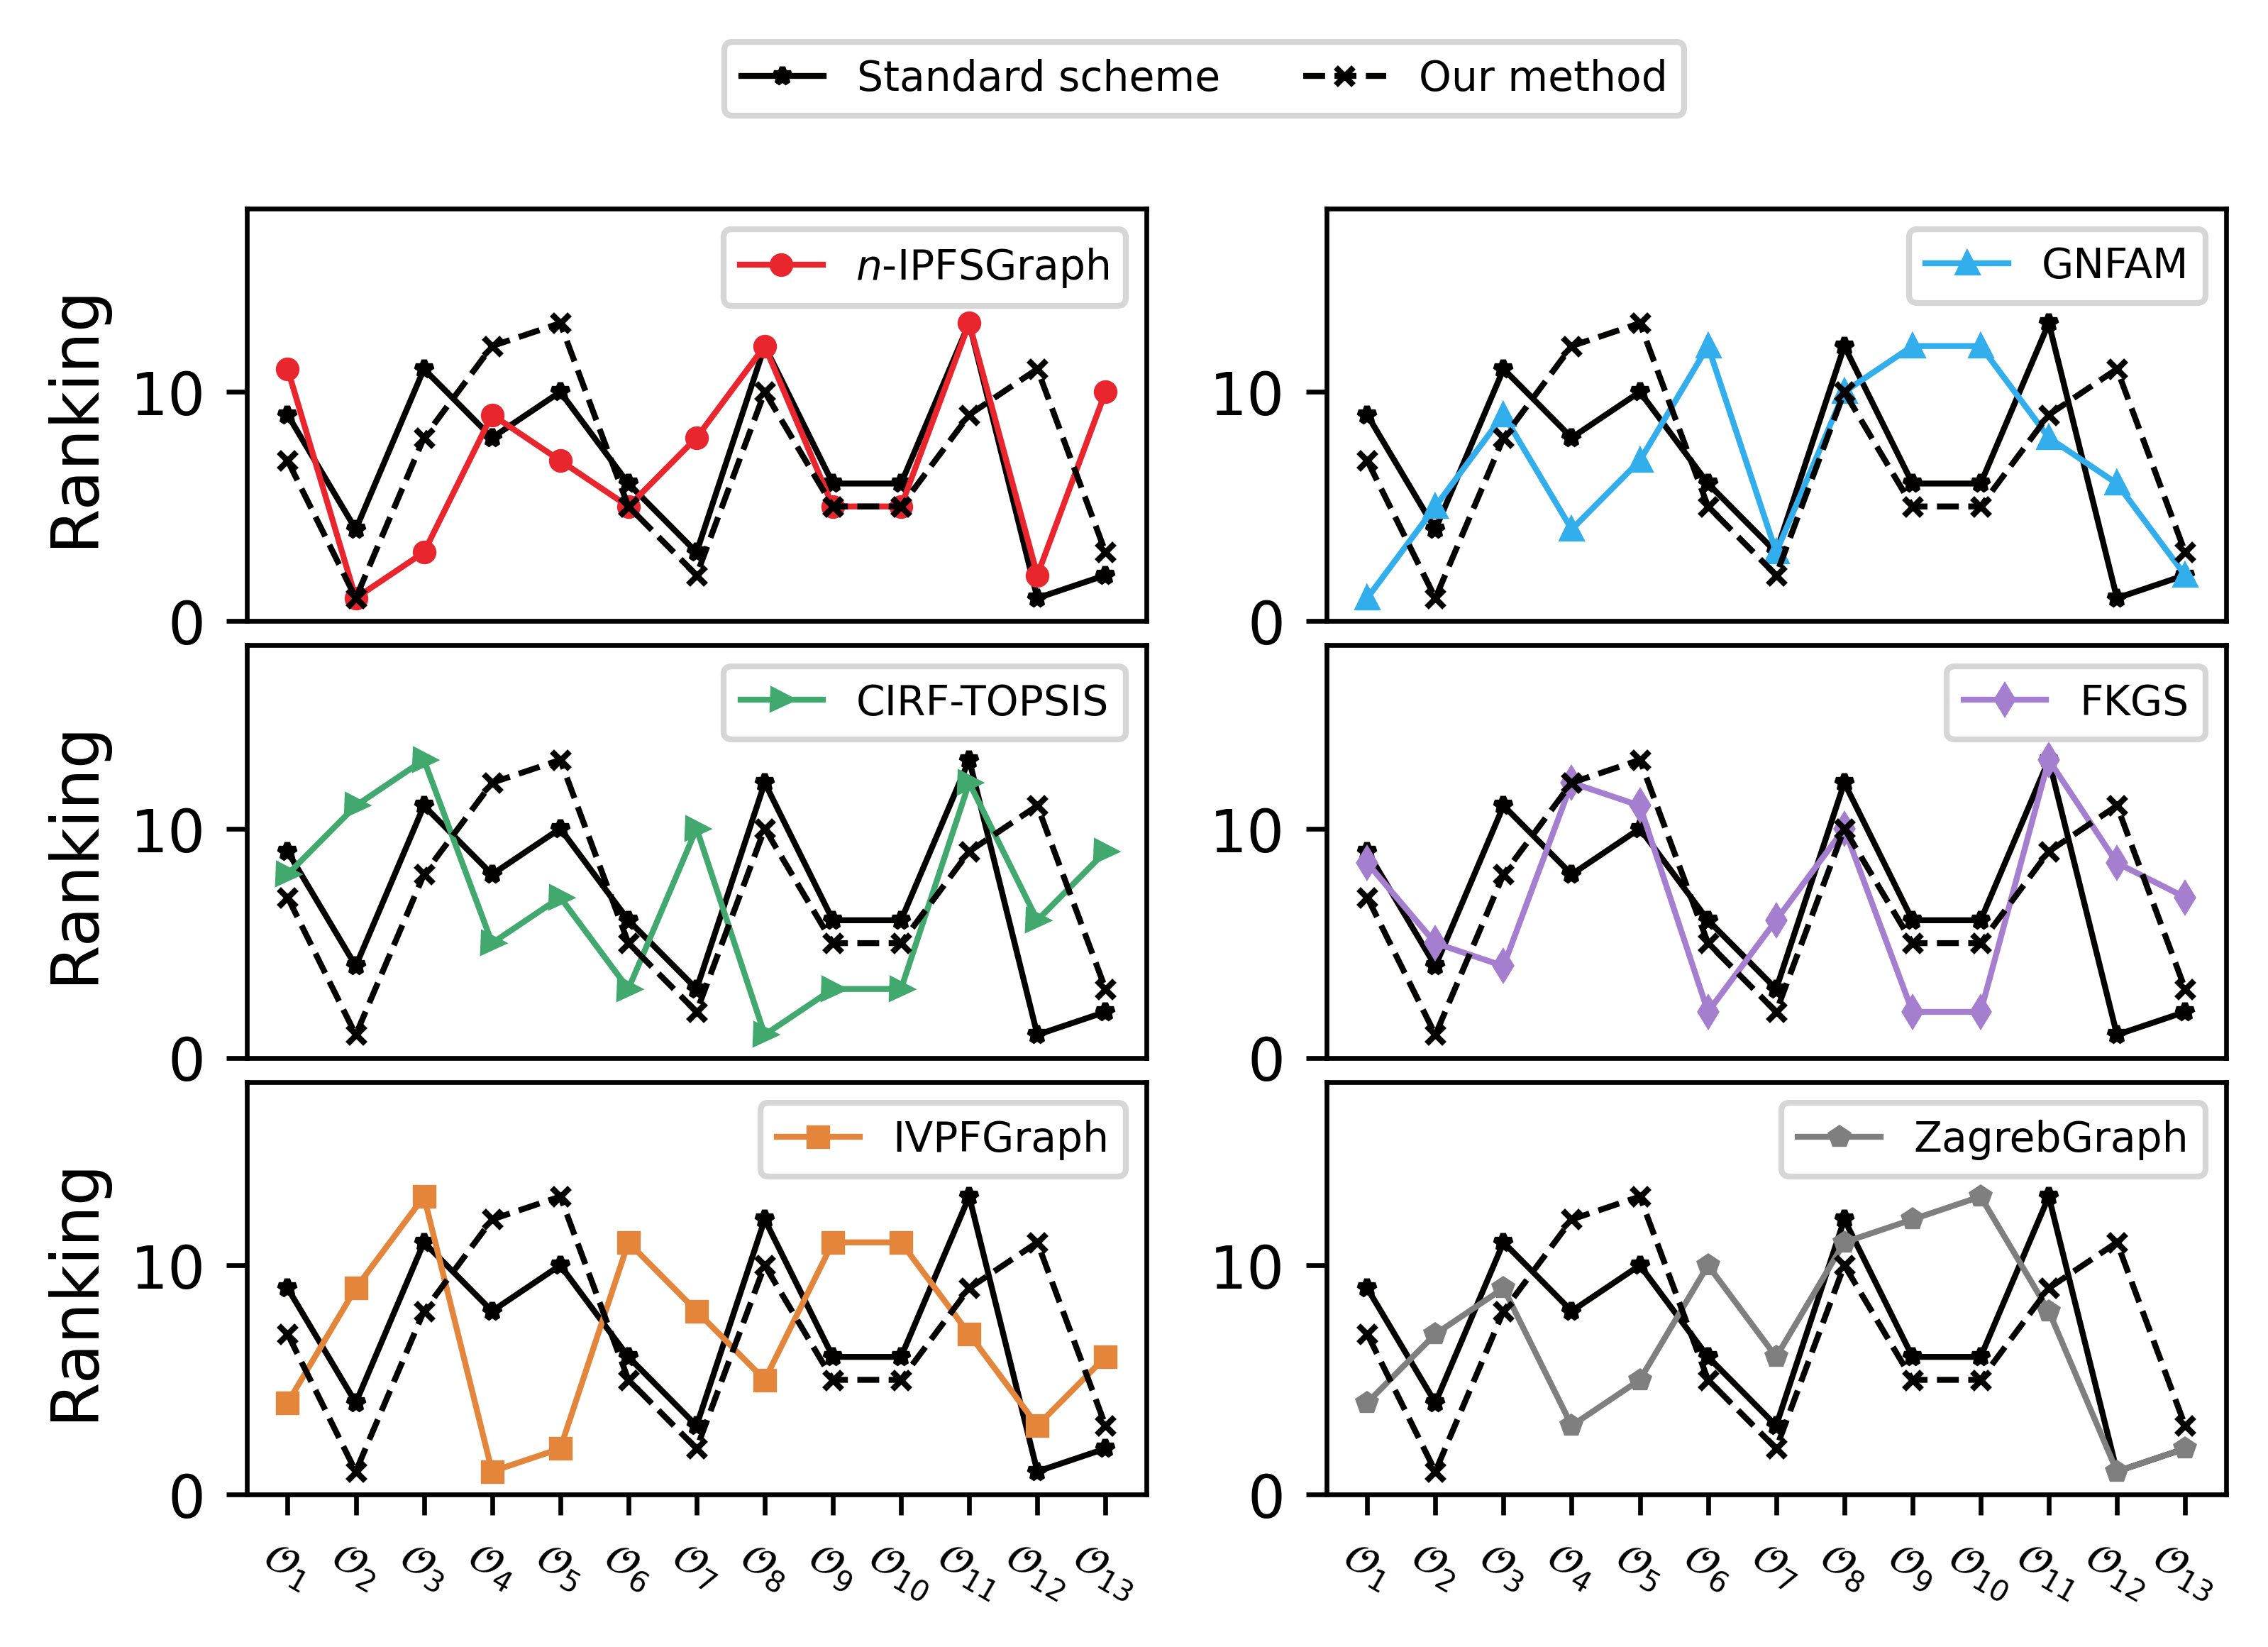

In [6]:
from matplotlib.gridspec import GridSpec
x = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2]
Name = [r'$\mathcal{O}_{1}$', r'$\mathcal{O}_{2}$', r'$\mathcal{O}_{3}$', r'$\mathcal{O}_{4}$', r'$\mathcal{O}_{5}$', r'$\mathcal{O}_{6}$', r'$\mathcal{O}_{7}$', r'$\mathcal{O}_{8}$', r'$\mathcal{O}_{9}$', r'$\mathcal{O}_{10}$', r'$\mathcal{O}_{11}$', r'$\mathcal{O}_{12}$', r'$\mathcal{O}_{13}$']
Name_none = ['','','','','','','','','','','','','']
# 顺序均为 O1, O2, ..., O13；并列对象使用平均名次
A0 = [9, 4, 11, 8, 10, 6, 3, 12, 6, 6, 13, 1, 2]       # Standard scheme
A_our = [7, 1, 8, 12, 13, 5, 2, 10, 5, 5, 9, 11, 3]   # Our method

A1 = [11, 1, 3, 9, 7, 5, 8, 12, 5, 5, 13, 2, 10]      # n-IPFSGraph
A2 = [1, 5, 9, 4, 7, 12, 3, 10, 12, 12, 8, 6, 2]     # GNFAM
A3 = [8, 11, 13, 5, 7, 3, 10, 1, 3, 3, 12, 6, 9]     # CIRF-TOPSIS
A4 = [8.5, 5, 4, 12, 11, 2, 6, 10, 2, 2, 13, 8.5, 7] # FKGS
A5 = [4, 9, 13, 1, 2, 11, 8, 5, 11, 11, 7, 3, 6]    # IVPFGraph
A6 = [4, 7, 9, 3, 5, 10, 6, 11, 12, 13, 8, 1, 2]    # ZagrebGraph

fig = plt.figure(dpi = 600)
# method1：GridSpec(nrow,ncol)函数：把子图网格化
gs = GridSpec(9, 2) # 生成一个9行3列的子图网格，传出的数据是数组
sub1 = fig.add_subplot(gs[0:3, 0]) # 一个subplot可以占用多个GridSpace网格。其中0:3取得的数组下标为0、1、2，分别代表第1、2、3行。
sub2 = fig.add_subplot(gs[0:3, 1])
sub3 = fig.add_subplot(gs[3:6, 0])
sub4 = fig.add_subplot(gs[3:6, 1])
sub5 = fig.add_subplot(gs[6:9, 0])
sub6 = fig.add_subplot(gs[6:9, 1])
fig.tight_layout()


line1 = sub1.plot(x, A0, color = '#030100', label = 'Standard scheme', 
                 marker = '*', markersize = 3, linewidth = 1)
line2 = sub1.plot(x, A1, color = '#E9262E', label = r'$\varsigma$=1', 
                 marker = 'o', markersize = 3, linewidth = 1)
# sub1.set_xlabel('Jurisdiction', fontsize = 11)
sub1.set_ylabel('Ranking', fontsize = 11)

sub1.tick_params(axis='x', which='both', bottom=False, top=False)  # 隐藏刻度线
sub1.set_xticklabels([])  # 隐藏刻度标签
# sub1.set_xticks(x) # 设置x轴主刻度
# sub1.set_xticklabels(Name, fontsize = 7, rotation = -30) # 设置x轴主刻度标签
sub1.set_ylim([0, 18])
sub1.legend(prop = {'size': 7}, ncol = 2, loc = 'upper right')


line1 = sub2.plot(x, A0, color = '#030100', label = 'Standard scheme', 
                 marker = '*', markersize = 3, linewidth = 1)
line2 = sub2.plot(x, A2, color = '#32AEEC', label = r'$\varsigma$=2', 
                 marker = '^', markersize = 3, linewidth = 1)
sub2.tick_params(axis='x', which='both', bottom=False, top=False)  # 隐藏刻度线
sub2.set_xticklabels([])  # 隐藏刻度标签
sub2.set_ylim([0, 18])
sub2.legend(prop = {'size': 7}, ncol = 2, loc = 'upper right')


line1 = sub3.plot(x, A0, color = '#030100', label = 'Standard scheme', 
                 marker = '*', markersize = 3, linewidth = 1)
line2 = sub3.plot(x, A3, color = '#41A96E', label = r'$\varsigma$=3', 
                 marker = '>', markersize = 3, linewidth = 1)
sub3.set_ylabel('Ranking', fontsize = 11)
sub3.tick_params(axis='x', which='both', bottom=False, top=False)  # 隐藏刻度线
sub3.set_xticklabels([])  # 隐藏刻度标签
sub3.set_ylim([0, 18])
sub3.legend(prop = {'size': 7}, ncol = 2, loc = 'upper right')


line1 = sub4.plot(x, A0, color = '#030100', label = 'Standard scheme', 
                 marker = '*', markersize = 3, linewidth = 1)
line2 = sub4.plot(x, A4, color = '#A57ED0', label = r'$\varsigma$=4', 
                 marker = 'd', markersize = 3, linewidth = 1)
sub4.tick_params(axis='x', which='both', bottom=False, top=False)  # 隐藏刻度线
sub4.set_xticklabels([])  # 隐藏刻度标签
sub4.set_ylim([0, 18])
sub4.legend(prop = {'size': 7}, ncol = 2, loc = 'upper right')


line1 = sub5.plot(x, A0, color = '#030100', label = 'Standard scheme', 
                 marker = '*', markersize = 3, linewidth = 1)
line2 = sub5.plot(x, A5, color = '#E3863C', label = r'$\varsigma$=5', 
                 marker = 's', markersize = 3, linewidth = 1)
sub1.set_xlabel('Jurisdiction', fontsize = 11)
sub5.set_ylabel('Ranking', fontsize = 11)

sub5.set_xticks(x) # 设置x轴主刻度
sub5.set_xticklabels(Name, fontsize = 7, rotation = -30) # 设置x轴主刻度标签
sub5.set_ylim([0, 18])
sub5.legend(prop = {'size': 7}, ncol = 2, loc = 'upper right')

line1 = sub6.plot(x, A0, color = '#030100', label = 'Standard scheme', 
                 marker = '*', markersize = 3, linewidth = 1)
line2 = sub6.plot(x, A6, color = '#7F7F7F', label = r'$\varsigma$=6', 
                 marker = 'p', markersize = 3, linewidth = 1)
sub1.set_xlabel('Jurisdiction', fontsize = 11)

sub6.set_xticks(x) # 设置x轴主刻度
sub6.set_xticklabels(Name, fontsize = 7, rotation = -30) # 设置x轴主刻度标签
sub6.set_ylim([0, 18])
sub6.legend(prop = {'size': 7}, ncol = 2, loc = 'upper right')

subplots = [sub1, sub2, sub3, sub4, sub5, sub6]
baseline_names = [
    r'$n$-IPFSGraph', 'GNFAM', 'CIRF-TOPSIS',
    'FKGS', 'IVPFGraph', 'ZagrebGraph'
]

for ax, baseline_name in zip(subplots, baseline_names):
    ax.plot(
        x, A_our,
        color='#030100', linestyle='--',
        marker='x', markersize=3, linewidth=1,
        label='Our method'
    )

    # 原有第2条线就是该子图的基线；子图图例只显示它
    ax.legend(
        [ax.lines[1]], [baseline_name],
        prop={'size': 7}, ncol=2, loc='upper right'
    )

# 两条公共曲线只在整张图的图例中出现一次
fig.legend(
    [sub1.lines[0], sub1.lines[2]],
    ['Standard scheme', 'Our method'],
    loc='upper center',
    bbox_to_anchor=(0.5, 0.99),
    ncol=2,
    prop={'size': 7}
)

fig.tight_layout(rect=(0, 0, 1, 0.94))

plt.savefig("./figCom6.jpg")

plt.show()
plt.close(fig)

<ipython-input-4-7c4471aa8e9a>:42: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  fig.tight_layout(rect=(0, 0, 1, 0.94))


# 比较分析1;2;3

In [141]:
"""
Our Method
"""
Score_paixu_id0 = [11, 6, 9, 10, 3, 13, 5, 1, 12, 7, 2, 4, 8]
Scheme0 = Scheme(Score_paixu_id0)
print(Scheme0)

['O11', 'O6', 'O9', 'O10', 'O3', 'O13', 'O5', 'O1', 'O12', 'O7', 'O2', 'O4', 'O8']


In [215]:

# 测试数据：三种排序方法
methods = [['O2', 'O13', 'O9', 'O10', 'O6', 'O3', 'O7', 'O1', 'O11', 'O8', 'O12', 'O5', 'O4'], # Our
           ['O2',  'O13', 'O9',  'O1',  'O8', 'O6', 'O11', 'O5', 'O4',  'O3', 'O7',  'O12', 'O10'],# Method 1
           ['O2', 'O13', 'O10', 'O1', 'O5', 'O8', 'O7', 'O12', 'O6', 'O9', 'O3', 'O11', 'O4'],# Method 2
           ['O2', 'O1', 'O13', 'O4', 'O6', 'O7', 'O8', 'O5', 'O9', 'O3', 'O10', 'O12', 'O11'],# Method 3
           ['O2', 'O8', 'O6', 'O9', 'O3', 'O11', 'O10', 'O7', 'O13', 'O1', 'O12', 'O5', 'O4'],# Method 4
           ['O13', 'O6', 'O9', 'O10', 'O3', 'O11', 'O5', 'O1', 'O12', 'O7', 'O2', 'O4', 'O8'],# Method 5
           ['O2', 'O13', 'O11', 'O10', 'O7', 'O6', 'O3', 'O1', 'O9', 'O8', 'O12', 'O5', 'O4'],# Method 6
           ['O2', 'O13', 'O10', 'O7', 'O3', 'O9', 'O6', 'O1', 'O8', 'O11', 'O12', 'O5', 'O4']] # Method 7

kemeny_young_sort = kemeny_young_heuristic(methods)
print("Kemeny-Young 近似排序:", kemeny_young_sort)
# 创建参考排序的排名映射
reference_rank_map = create_rank_map(kemeny_young_sort)

# 计算每个方法的正确率
accuracies = []
for method_sort in methods:
    correct_pairs, total_pairs = count_correct_pairs(method_sort, reference_rank_map)
    accuracy = correct_pairs / total_pairs if total_pairs > 0 else 0
    accuracies.append(accuracy)

# 输出结果
print(accuracies)

Kemeny-Young 近似排序: ['O2', 'O13', 'O6', 'O9', 'O10', 'O3', 'O1', 'O8', 'O7', 'O11', 'O5', 'O12', 'O4']
[0.9230769230769231, 0.7435897435897436, 0.7307692307692307, 0.6538461538461539, 0.7692307692307693, 0.7435897435897436, 0.782051282051282, 0.8589743589743589]


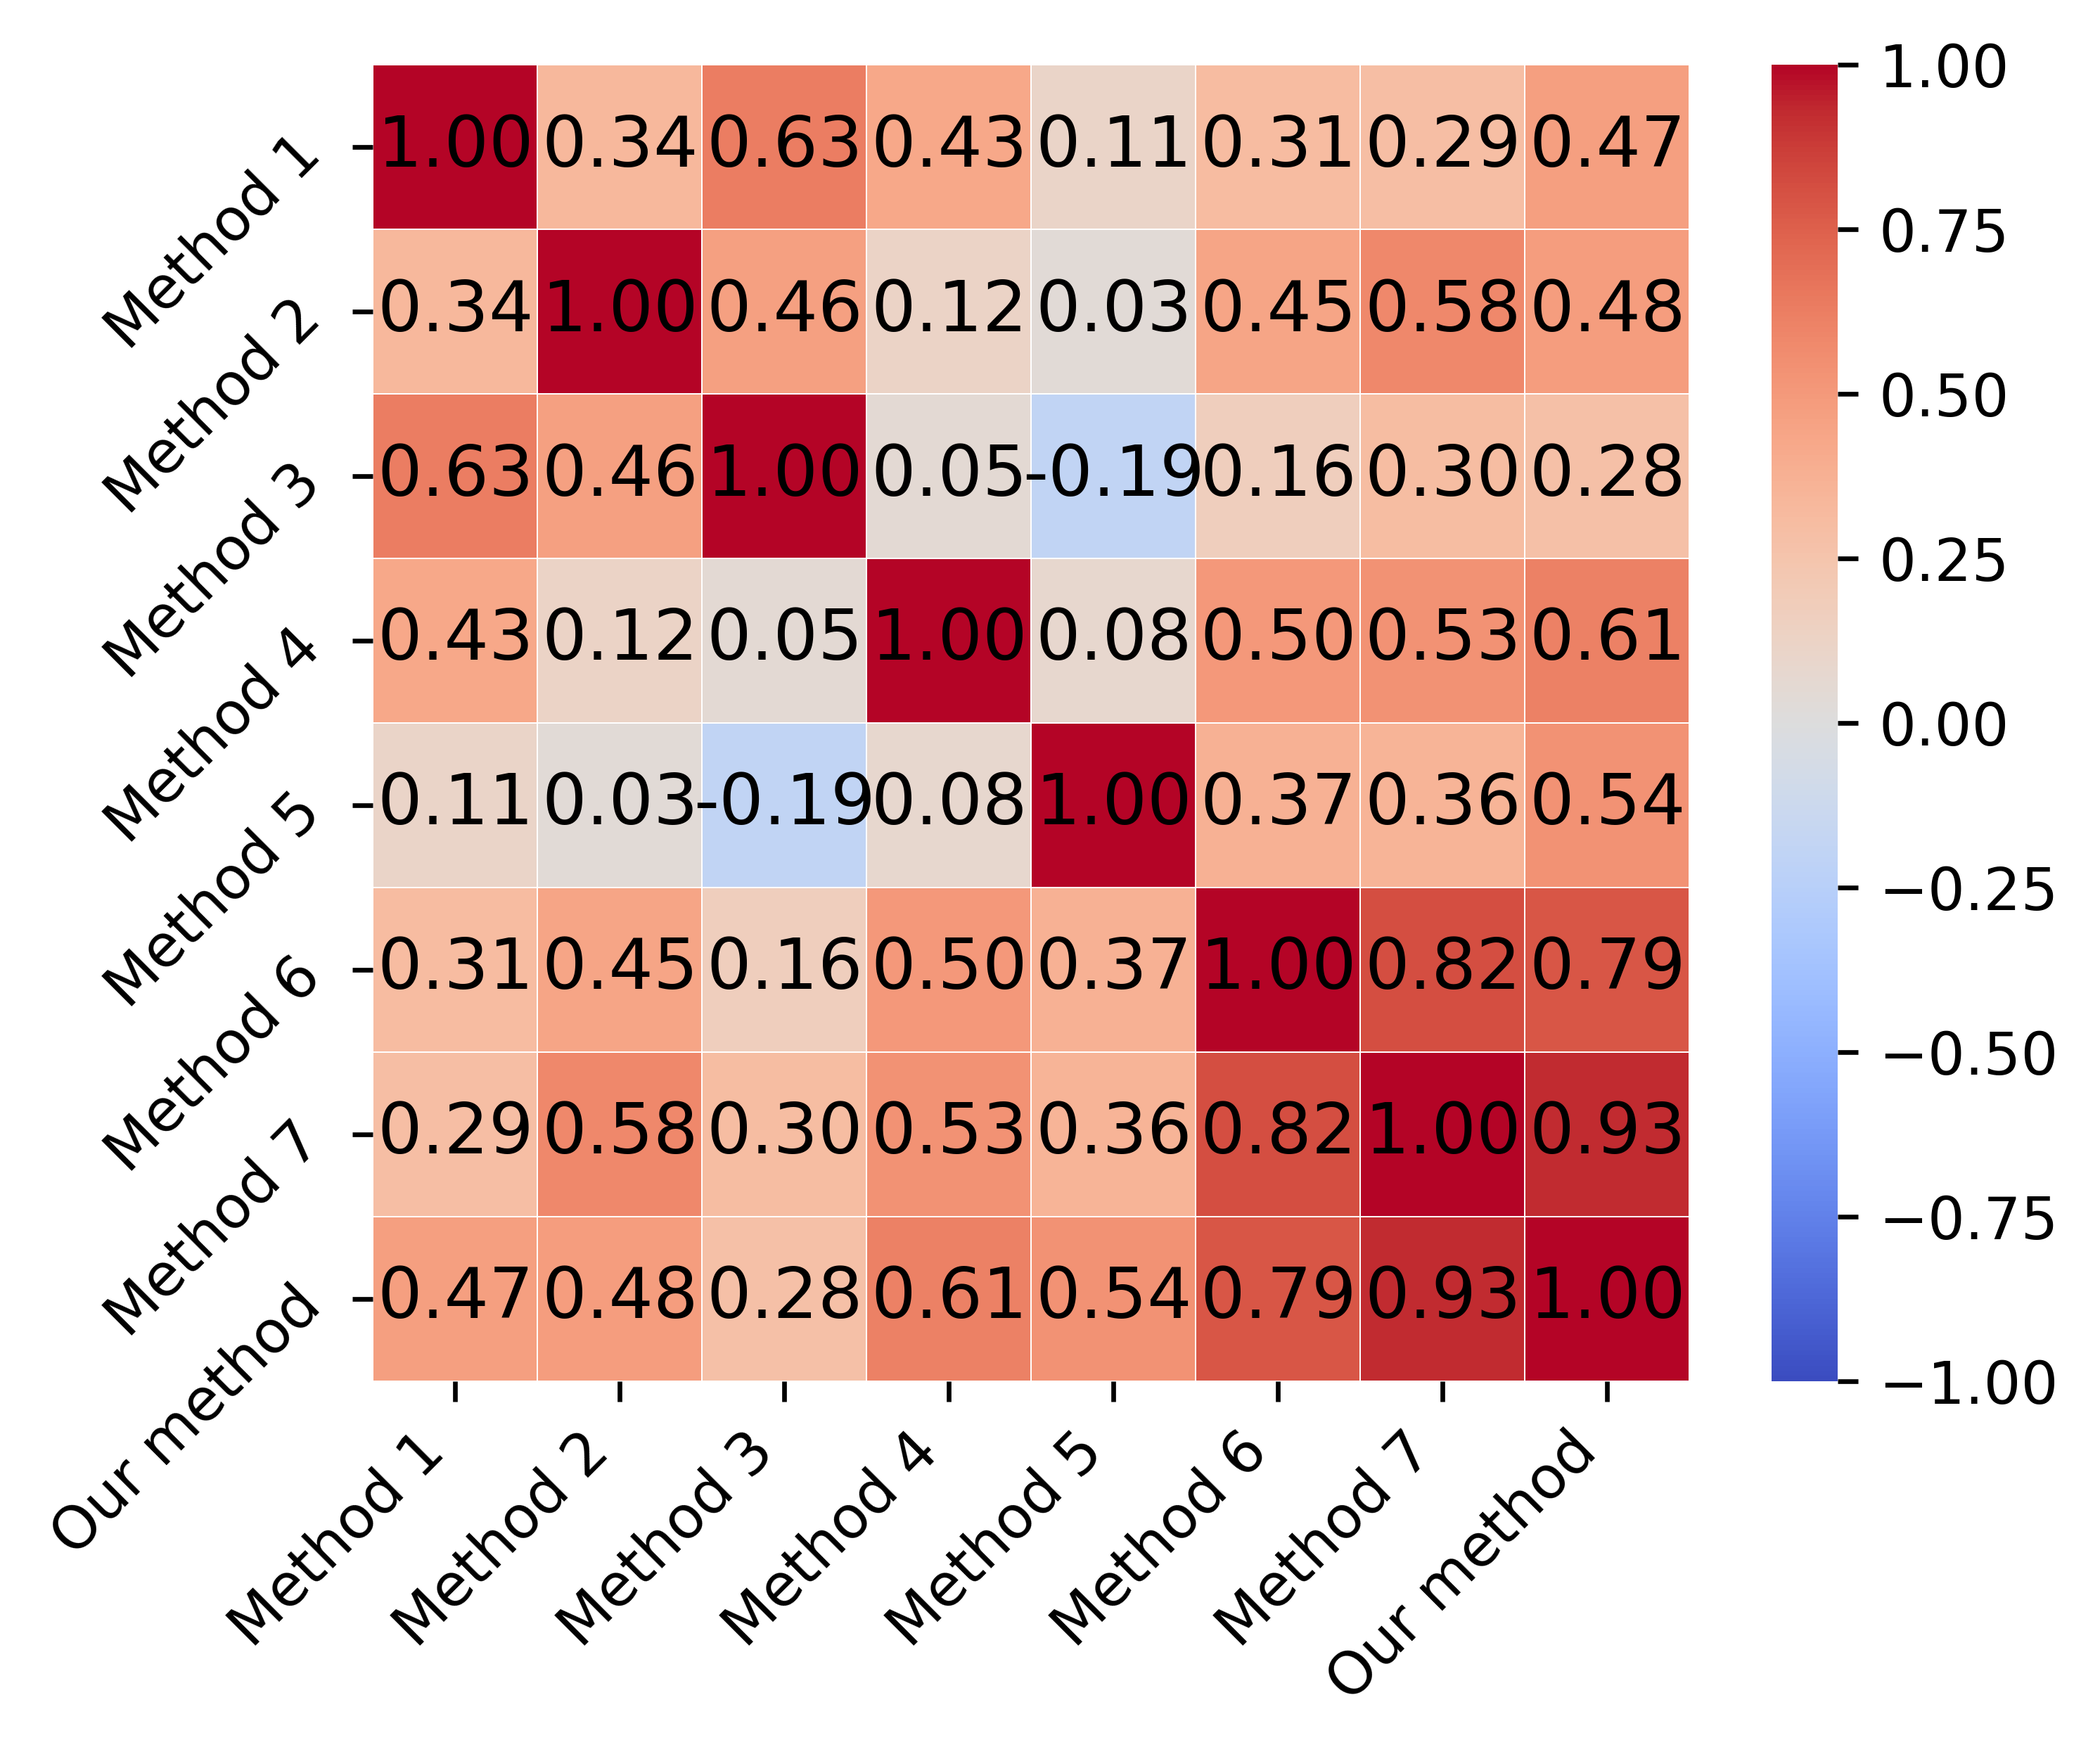

In [220]:
data = pd.read_csv('rlt_data1.csv', encoding="gbk")
d = pd.DataFrame(data)
dcorr = d.corr(method='spearman')
fig = plt.figure(figsize = (6,6),dpi = 600)
ax = fig.add_axes([0.20, 0.20, 0.65, 0.65])
sns.heatmap(data=dcorr,
            ax=ax,
            vmax=1,
            vmin=-1,
            center = 0,
            cmap = plt.get_cmap('coolwarm'), 
            annot=True,#图中数字文本显示
            fmt=".2f",#格式化输出图中数字，即保留小数位数等
            annot_kws={'size':12, 'weight':'normal', 'color':'#000000'},
            square=True, linewidths=0.2,#每个方格外框显示，外框宽度设置
            cbar_kws={"shrink": 0.8}
           )

# 坐标轴标签
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha='right'
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=45
)

plt.savefig("./rlt1.jpg", dpi=600)

plt.show()
plt.close(fig)

In [225]:
"""
Our Method
"""
Score_paixu_id0 = [2, 13, 9, 10, 7, 6, 3, 1, 11, 8, 12, 5, 4]
Scheme0 = Scheme(Score_paixu_id0)
print(Scheme0)

['O2', 'O13', 'O9', 'O10', 'O7', 'O6', 'O3', 'O1', 'O11', 'O8', 'O12', 'O5', 'O4']


In [194]:

# 测试数据：三种排序方法
methods = [['O2', 'O13', 'O9', 'O10', 'O6', 'O3', 'O7', 'O1', 'O11', 'O8', 'O12', 'O5', 'O4'], # Our
           ['O9', 'O10', 'O12', 'O3', 'O4', 'O5', 'O8', 'O13', 'O1', 'O7', 'O11', 'O2', 'O6'],# Non
           ['O2', 'O13', 'O7', 'O9', 'O10', 'O8', 'O1', 'O12', 'O11', 'O6', 'O5', 'O3', 'O4'],# SAGE
           ['O2', 'O13', 'O9', 'O10', 'O3', 'O6', 'O11', 'O7', 'O8', 'O4', 'O1', 'O12', 'O5'],# GAT
           ['O2', 'O13', 'O10', 'O1', 'O8', 'O11', 'O3', 'O7', 'O6', 'O12', 'O9', 'O5', 'O4']]# ChetNwt

kemeny_young_sort = kemeny_young_heuristic(methods)
print("Kemeny-Young 近似排序:", kemeny_young_sort)
# 创建参考排序的排名映射
reference_rank_map = create_rank_map(kemeny_young_sort)

# 计算每个方法的正确率
accuracies = []
for method_sort in methods:
    correct_pairs, total_pairs = count_correct_pairs(method_sort, reference_rank_map)
    accuracy = correct_pairs / total_pairs if total_pairs > 0 else 0
    accuracies.append(accuracy)

# 输出结果
print(accuracies)

Kemeny-Young 近似排序: ['O2', 'O13', 'O9', 'O10', 'O3', 'O7', 'O8', 'O1', 'O11', 'O6', 'O12', 'O5', 'O4']
[0.9102564102564102, 0.5256410256410257, 0.8589743589743589, 0.8717948717948718, 0.8076923076923077]


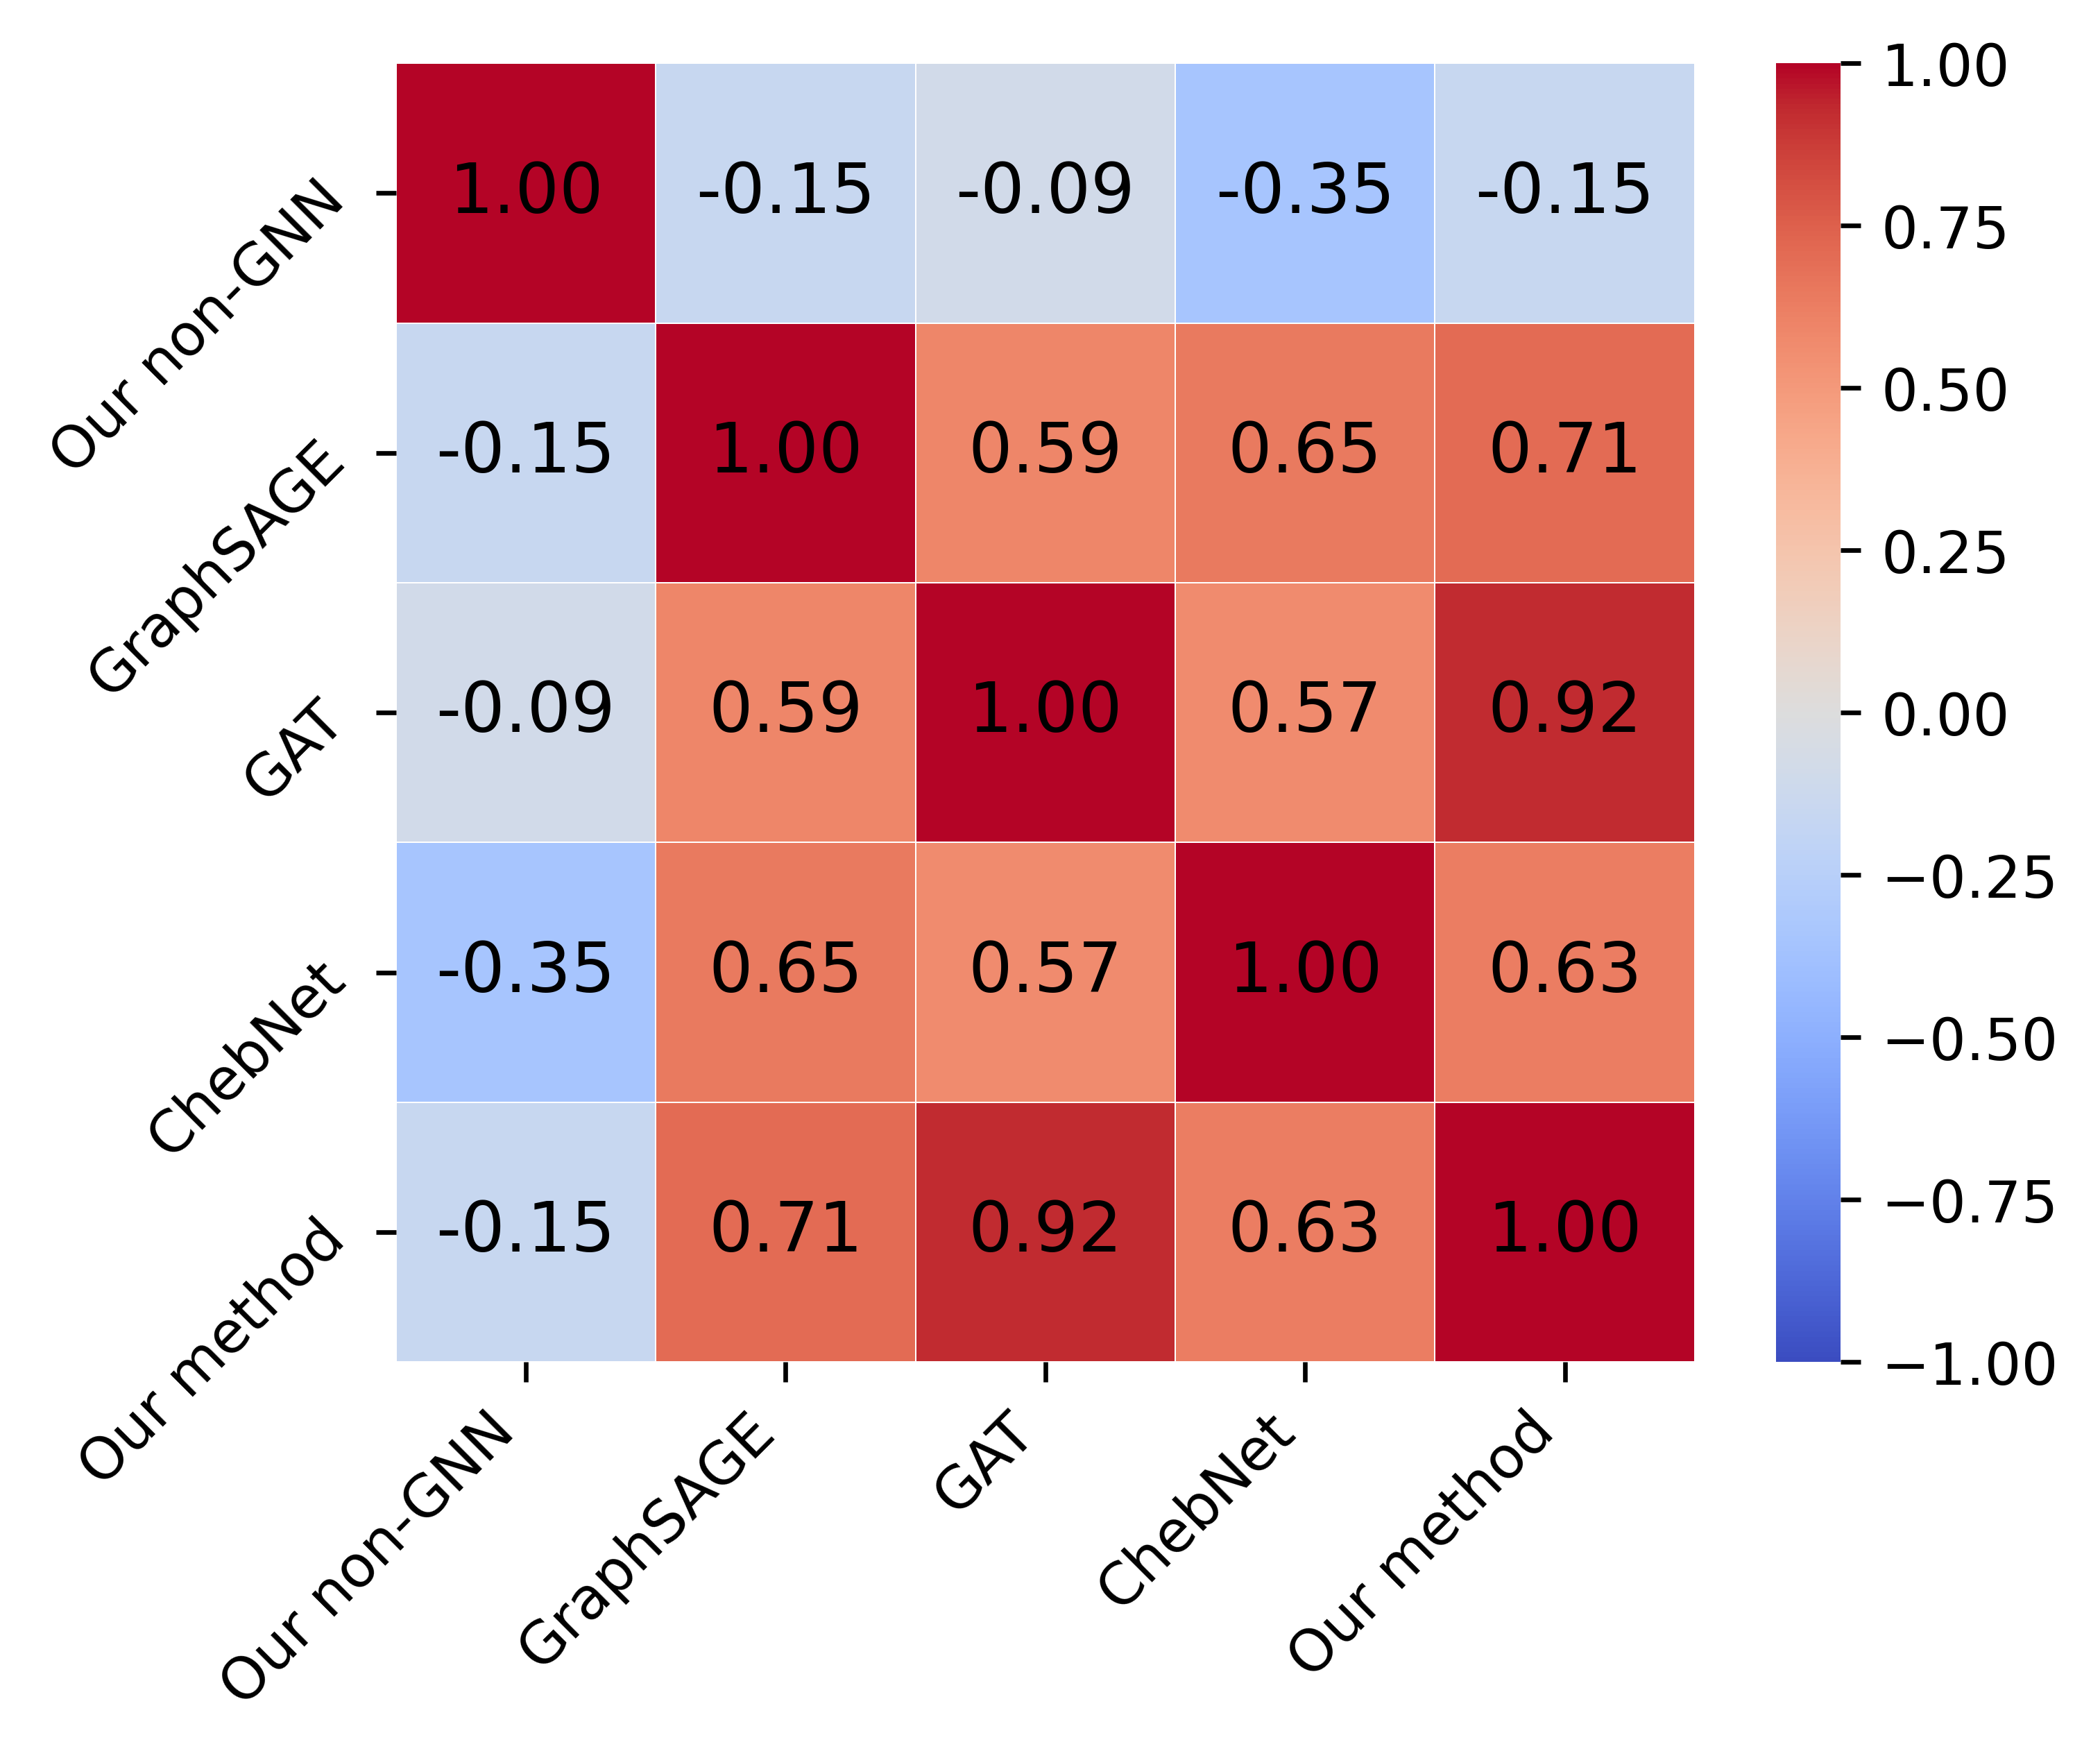

In [221]:
data = pd.read_csv('rlt_data2.csv', encoding="gbk")
d = pd.DataFrame(data)
dcorr = d.corr(method='spearman')
fig = plt.figure(figsize = (6,6),dpi = 600)
ax = fig.add_axes([0.20, 0.20, 0.65, 0.65])
sns.heatmap(data=dcorr,
            ax=ax,
            vmax=1,
            vmin=-1,
            center = 0,
            cmap = plt.get_cmap('coolwarm'), 
            annot=True,#图中数字文本显示
            fmt=".2f",#格式化输出图中数字，即保留小数位数等
            annot_kws={'size':12, 'weight':'normal', 'color':'#000000'},
            square=True, linewidths=0.2,#每个方格外框显示，外框宽度设置
            cbar_kws={"shrink": 0.8}
           )

# 坐标轴标签
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha='right'
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=45
)
plt.savefig("./rlt2.jpg", dpi=600)

plt.show()
plt.close(fig)

In [219]:

# 测试数据：三种排序方法
methods = [['O2', 'O13', 'O9', 'O10', 'O6', 'O3', 'O7', 'O1', 'O11', 'O8', 'O12', 'O5', 'O4'], # Our
           ['O2', 'O13', 'O9', 'O1', 'O8', 'O6', 'O11', 'O5', 'O4', 'O3', 'O7', 'O12', 'O10'],# AAPWA
           ['O13',  'O2', 'O9',  'O11',  'O8', 'O6', 'O1', 'O4', 'O5',  'O7', 'O3',  'O12', 'O10'],# AAPWG
           ['O13', 'O2', 'O9', 'O10', 'O6', 'O3', 'O7', 'O1', 'O12', 'O5', 'O11', 'O8', 'O4'],# GAAWG
           ['O2', 'O13', 'O9', 'O10', 'O7', 'O6', 'O3', 'O1', 'O5', 'O8', 'O12', 'O11', 'O4'],# GGAAWG
           ['O2', 'O13', 'O9', 'O10', 'O7', 'O6', 'O3', 'O1', 'O11', 'O5', 'O12', 'O8', 'O4']] # GWBM

kemeny_young_sort = kemeny_young_heuristic(methods)
print("Kemeny-Young 近似排序:", kemeny_young_sort)
# 创建参考排序的排名映射
reference_rank_map = create_rank_map(kemeny_young_sort)

# 计算每个方法的正确率
accuracies = []
for method_sort in methods:
    correct_pairs, total_pairs = count_correct_pairs(method_sort, reference_rank_map)
    accuracy = correct_pairs / total_pairs if total_pairs > 0 else 0
    accuracies.append(accuracy)

# 输出结果
print(accuracies)

Kemeny-Young 近似排序: ['O2', 'O13', 'O9', 'O10', 'O6', 'O7', 'O3', 'O1', 'O11', 'O8', 'O5', 'O12', 'O4']
[0.9743589743589743, 0.6923076923076923, 0.6666666666666666, 0.9102564102564102, 0.9358974358974359, 0.9615384615384616]


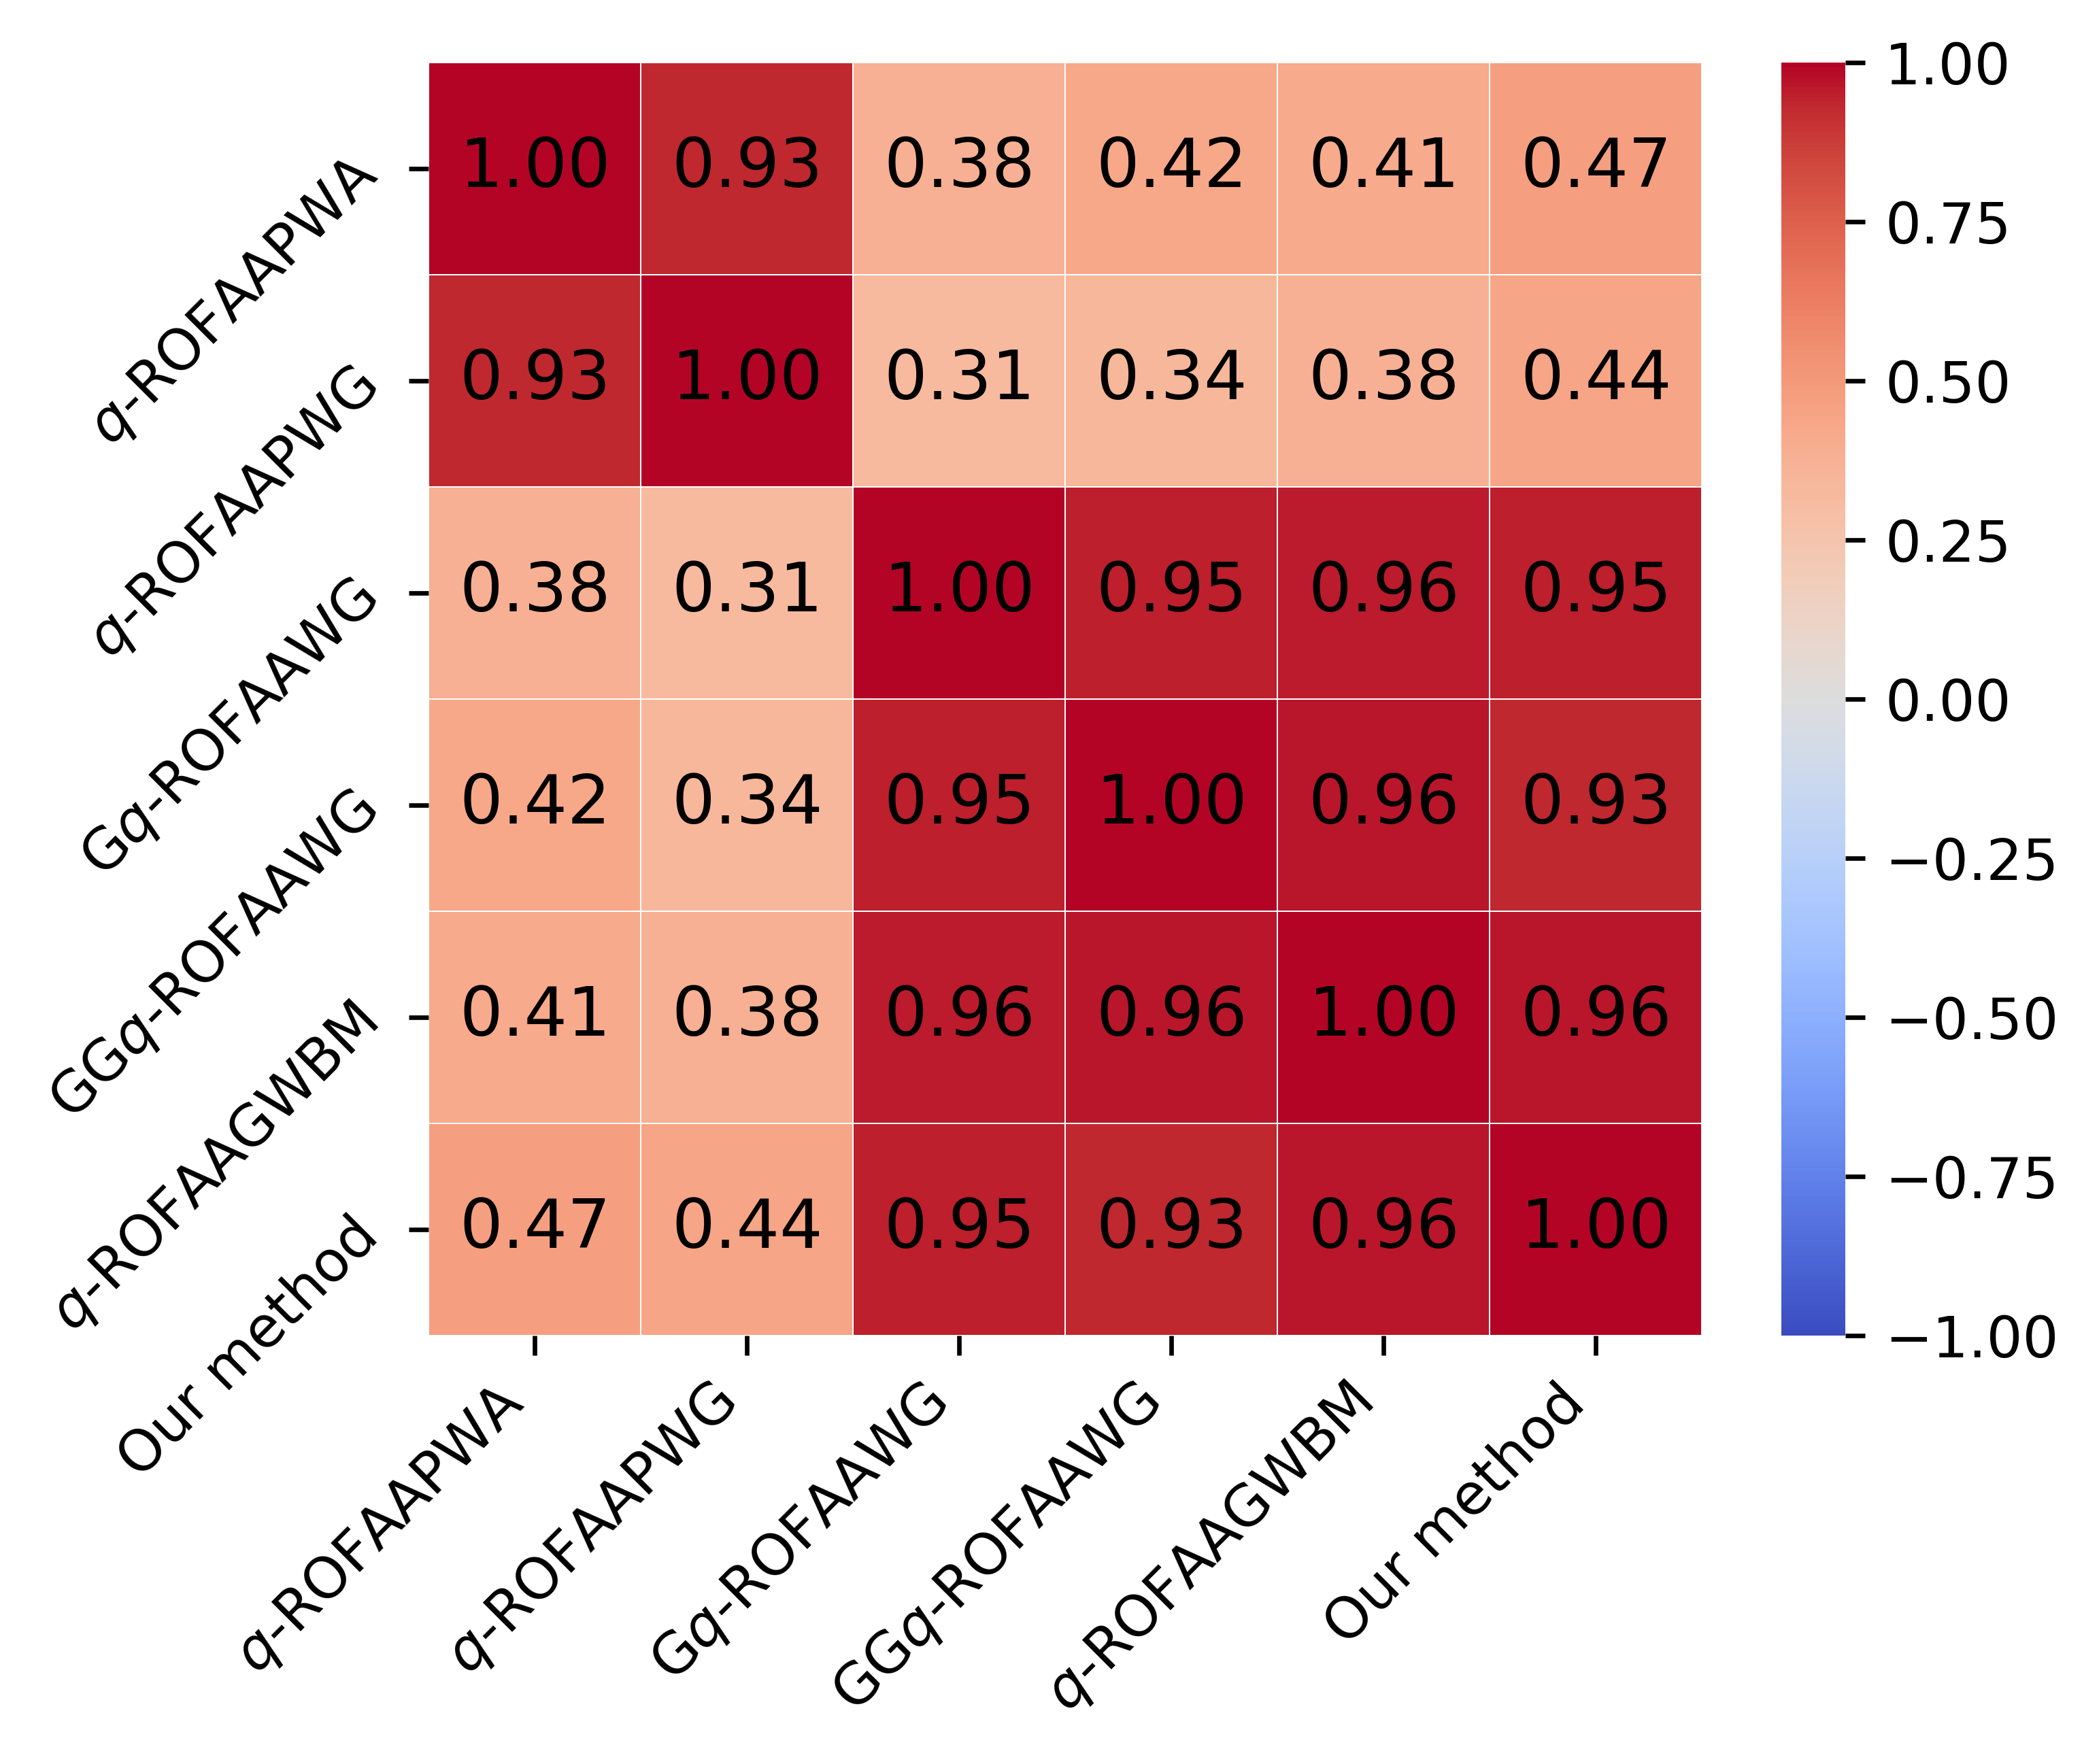

In [222]:
data = pd.read_csv('rlt_data3.csv', encoding="gbk")
d = pd.DataFrame(data)
dcorr = d.corr(method='spearman')
fig = plt.figure(figsize = (6,6),dpi = 600)
ax = fig.add_axes([0.20, 0.20, 0.65, 0.65])
sns.heatmap(data=dcorr,
            ax=ax,
            vmax=1,
            vmin=-1,
            center = 0,
            cmap = plt.get_cmap('coolwarm'), 
            annot=True,#图中数字文本显示
            fmt=".2f",#格式化输出图中数字，即保留小数位数等
            annot_kws={'size':12, 'weight':'normal', 'color':'#000000'},
            square=True, linewidths=0.2,#每个方格外框显示，外框宽度设置
            cbar_kws={"shrink": 0.8}
           )

# 坐标轴标签
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha='right'
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=45
)
plt.savefig("./rlt3.jpg", dpi=600)

plt.show()
plt.close(fig)